# **EDA To Prediction (DieTanic)**

# 프로젝트 목적 및 개요
- 분석 목표: 예측 모델링 문제의 전체적인 워크플로우(Workflow)를 파악함.

- 주요 학습 내용: 특성(Features) 확인, 새로운 특성 추가, 머신러닝 개념

# Part1: Exploratory Data Analysis(EDA)

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [114]:
data=pd.read_csv('train.csv')

In [115]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [116]:
#전체 null values 확인
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


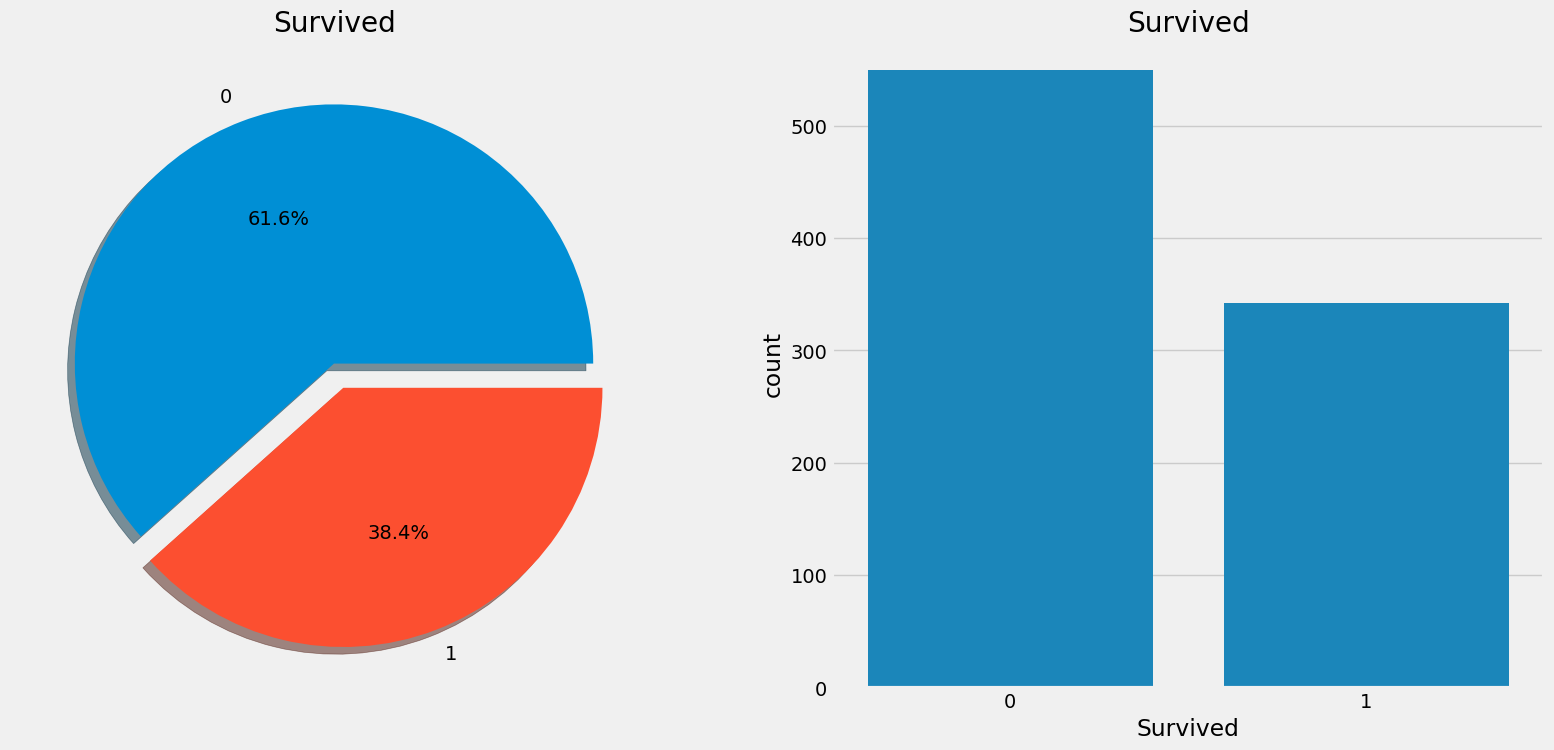

In [117]:
#생존자 수 확인
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
sns.countplot(x='Survived',data=data,ax=ax[1])
ax[1].set_title('Survived')
plt.show()

- 훈련 세트(Training set)의 전체 891명 중 약 350명(38.4%)만이 생존함.

- 주요 분석 대상 특성: 성별(Sex), 승선 항구(Port Of Embarcation), 연령(Age) 등.

# Types Of Features

1. 범주형 특성 (Categorical Features)

- 정의: 두 개 이상의 카테고리를 가지며, 각 값이 그중 하나로 분류될 수 있는 변수.

- 특징: 값들 사이에 순서를 정하거나 정렬할 수 없음. 명목 변수(Nominal Variables)라고도 불림.

- 예시: 성별(Sex), 승선 항구(Embarked).

2. 순서형 특성 (Ordinal Features)

- 정의: 범주형 값과 유사하지만, 값들 사이에 상대적인 순서나 정렬이 가능하다는 차이점이 있음.

- 특징: 값들 간의 상대적인 비교(예: 높음, 중간, 낮음)가 가능함.

- 예시: 티켓 등급(PClass).

3. 연속형 특성 (Continuous Features)

- 정의: 특정 열의 최솟값과 최댓값 사이, 또는 임의의 두 지점 사이에서 어떤 값이라도 가질 수 있는 특성.

- 예시: 연령(Age).

# Analysing The Features

### 1. Sex--> Categorical Feature

In [118]:
data.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

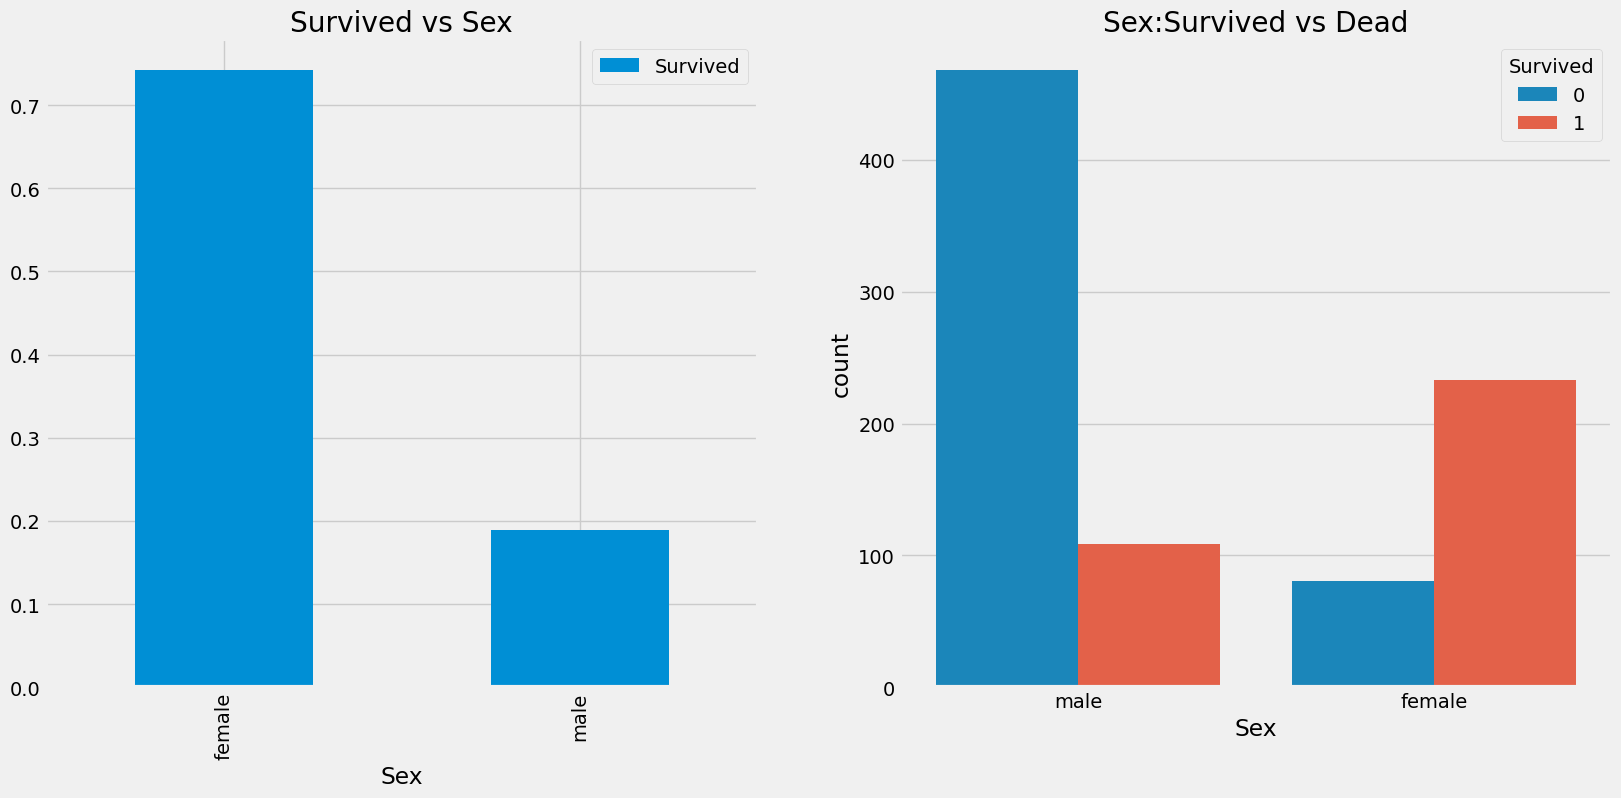

In [119]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex',hue='Survived',data=data, ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

- 배에 탑승한 남성의 수가 여성의 수보다 훨씬 많음.

- 남성보다 여성 생존자의 수가 거의 2배에 달함.

여성의 생존율: 약 75%

남성의 생존율: 약 18~19%

-> 성별은 모델링을 위한 매우 중요한 특성(Feature)으로 보임.

### 2. Pclass --> Ordinal Feauture


In [120]:
pd.crosstab(data.Pclass,data.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


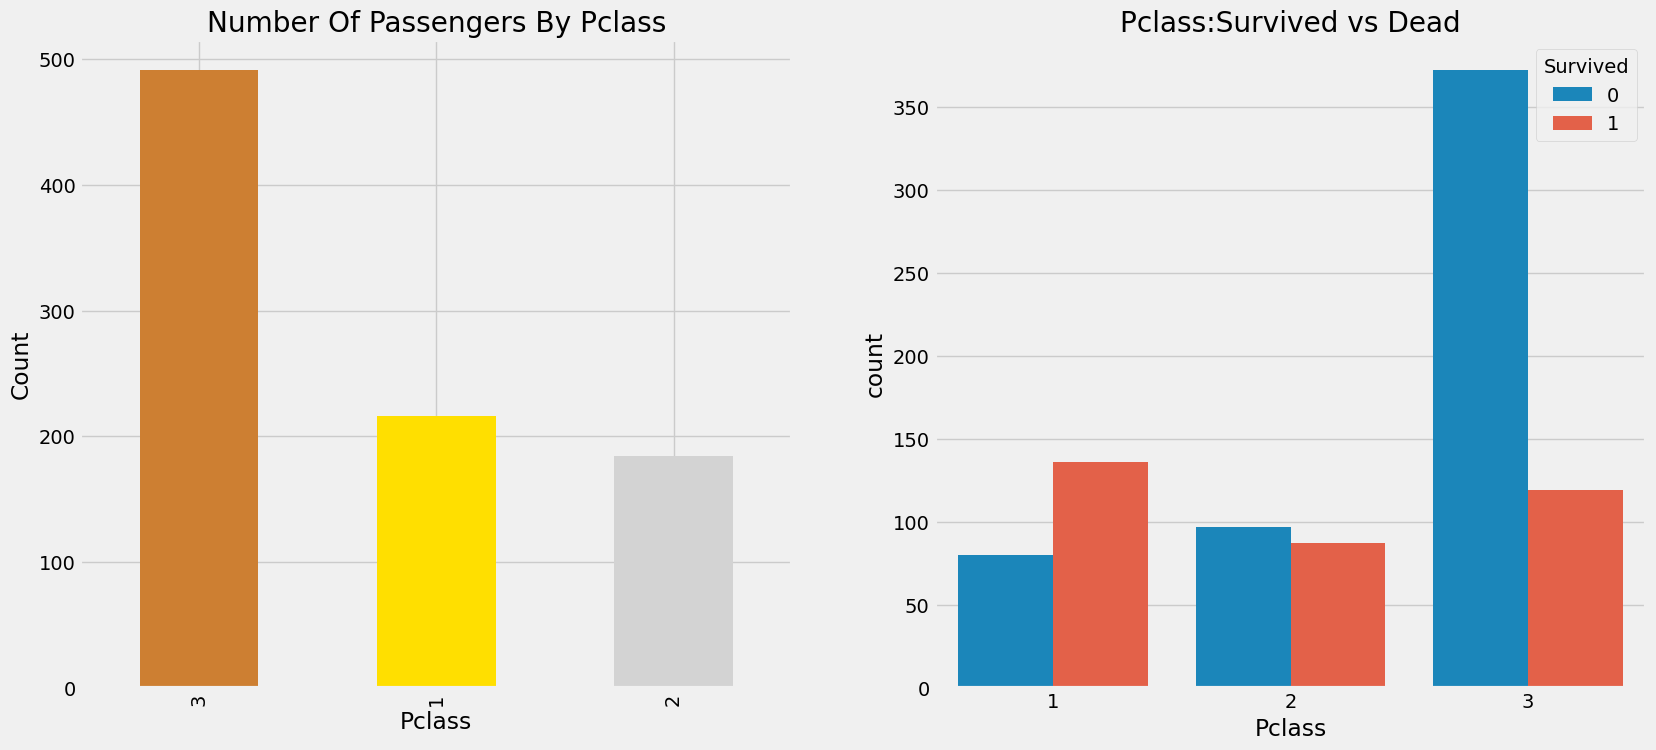

In [121]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

- Pclass 1등급 승객들이 구조 시 매우 높은 우선순위를 받았음을 명확히 알 수 있음.

- 등급별 생존율 비교:

Pclass 1: 생존율 약 63%

Pclass 2: 생존율 약 48%

Pclass 3: 승객 수는 훨씬 많았으나, 생존율은 약 25%로 매우 낮음.

-> 결과 : 돈과 사회적 지위(Status)가 구조에 영향을 미쳤음을 보여줌.

In [122]:
pd.crosstab([data.Sex,data.Survived],data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

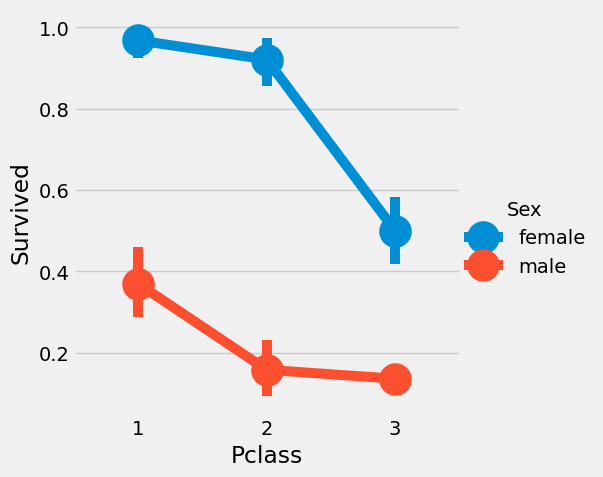

In [123]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',data=data, kind='point')
plt.show()

- FactorPlot: 범주형 값(Categorical values)을 쉽게 분리하여 시각화

- CrossTab: 변수 간의 관계를 표 형태로 교차 분석함.

- 주요 분석 결과:

Pclass 1 여성: 94명 중 단 3명만 사망하여 생존율이 약 95~96%에 달함.

-> 구조 우선순위: 티켓 등급(Pclass)과 관계없이 여성이 구조 시 최우선 순위였음이 명백함.

남성 생존율: Pclass 1 등급의 남성일지라도 생존율은 매우 낮음.

### 3. Age--> Continous Feature


In [124]:
print('Oldest Passenger was of:', data['Age'].max(), 'Years')
print('Youngest Passenger was of:', data['Age'].min(), 'Years')
print('Average Age on the ship:', data['Age'].mean(), 'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


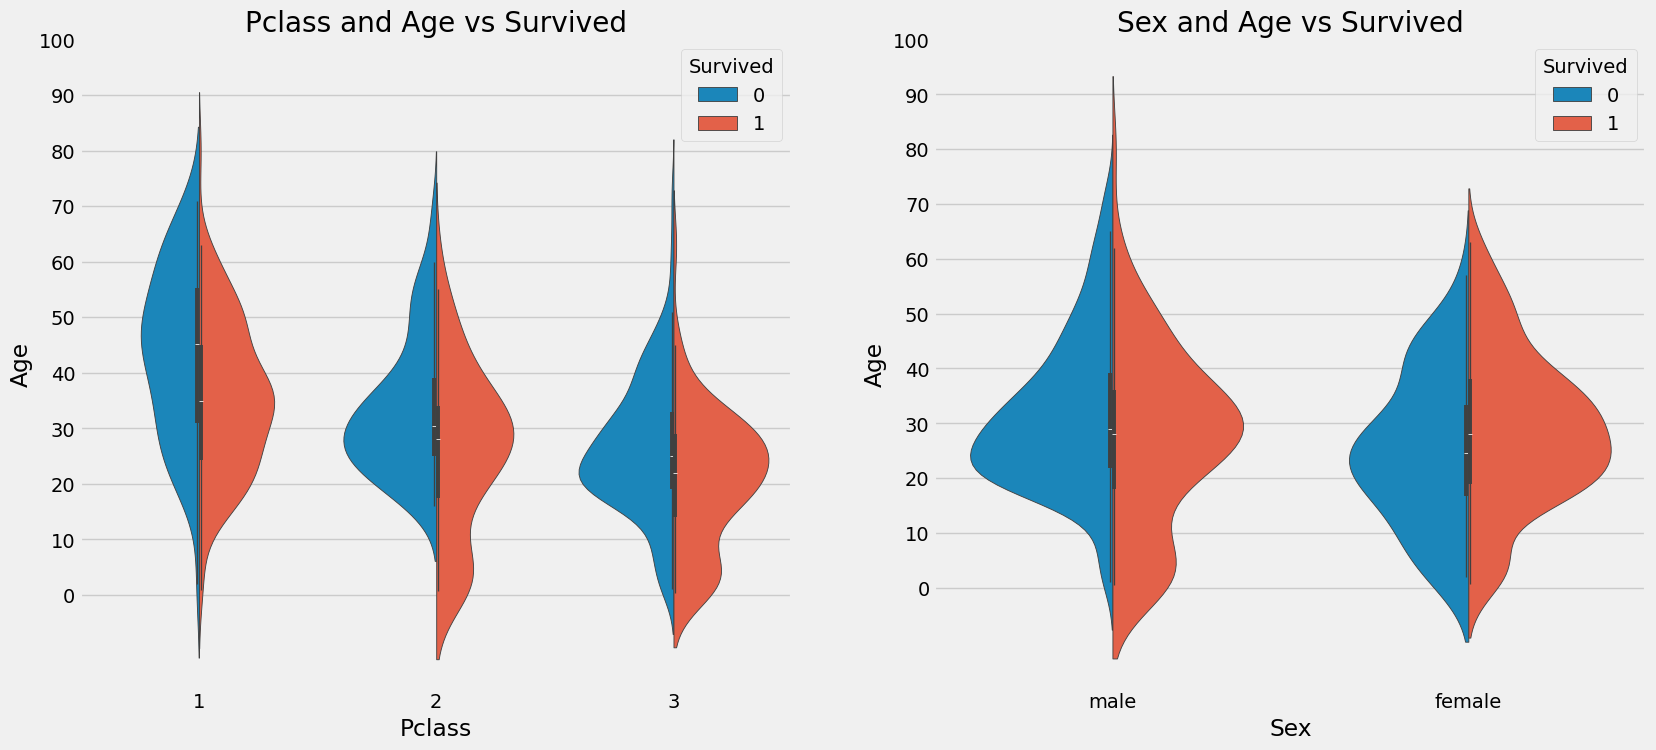

In [125]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass",y="Age", hue="Survived", data=data,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))
sns.violinplot(x="Sex",y="Age", hue="Survived", data=data,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

- 어린이 생존율: 티켓 등급(Pclass)이 낮아질수록 어린이 수가 증가하며, 10세 미만 어린이의 생존율은 Pclass와 관계없이 전반적으로 양호함.
- 20-50세(Pclass 1): 1등급석의 20-50세 승객은 생존 확률이 높으며, 특히 여성의 경우 더욱 높음.
- 남성 연령별 경향: 남성의 경우, 연령이 증가할수록 생존 확률이 감소함.


문제점: 연령 특성에는 177개의 결측치가 존재함. 전체 평균 연령(29세)으로 일괄 교체할 경우, 어린아이에게 성인 평균 나이를 부여하는 등의 오류가 발생함.

-> 해결 방안 (Feature Engineering): 이름(Name) 특성에 포함된 호칭(Salutation, 예: Mr, Mrs)을 활용함.
각 호칭별(Mr, Mrs 등)로 그룹을 나누어 해당 그룹의 평균 연령을 결측치에 할당

In [126]:
data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.') #lets extract the Salutations

사용된 정규표현식: '([A-Za-z]+)\.'

- A-Z 또는 a-z 사이에 있는 문자열을 탐색함.
- 문자열 뒤에 마침표(.)가 뒤따르는 패턴을 찾음.

In [127]:
pd.crosstab(data.Initial,data.Sex).T.style.background_gradient(cmap='summer_r') #Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [128]:
#호칭 데이터 정제
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)

In [129]:
#호칭별 평균 연령 확인
data.groupby('Initial')['Age'].mean()

,Age
Initial,
Master,4.574167
Miss,21.860000
Mr,32.739609
Mrs,35.981818
Other,45.888889


# Filling NaN Ages

In [130]:
#평균 연령의 올림값(Ceil)을 이용한 결측치 할당
data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age']=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age']=46

In [131]:
#결측치 처리 완료
data.Age.isnull().any()

np.False_

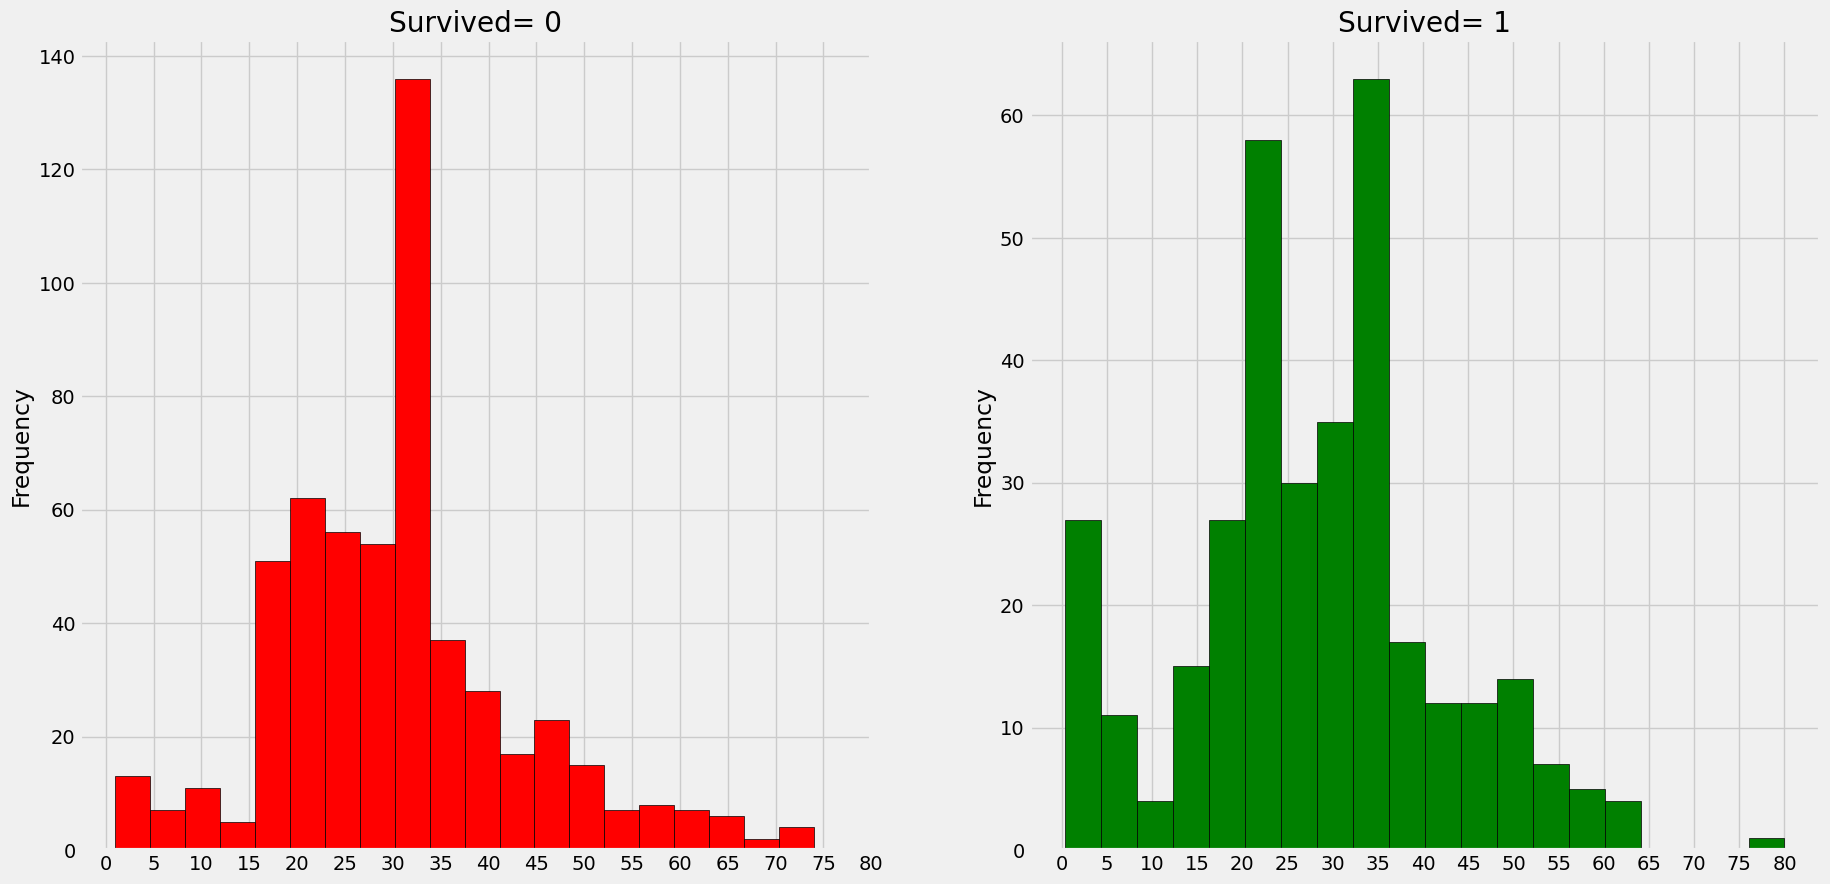

In [132]:
f,ax=plt.subplots(1,2,figsize=(20,10))
data[data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
data[data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

- 유아 및 영유아(Toddlers): 5세 미만의 아이들이 많이 구조됨. 이는 당시에 적용된 "여성과 아이 먼저(The Women and Child First Policy)"라는 구조 정책이 데이터에 반영된 결과임.

- 최고령 승객: 데이터셋 내의 최고령 승객(80세)이 생존한 것이 확인됨.

- 최다 사망 연령대: 가장 많은 사망자가 발생한 연령대는 30~40세 사이로 나타남.

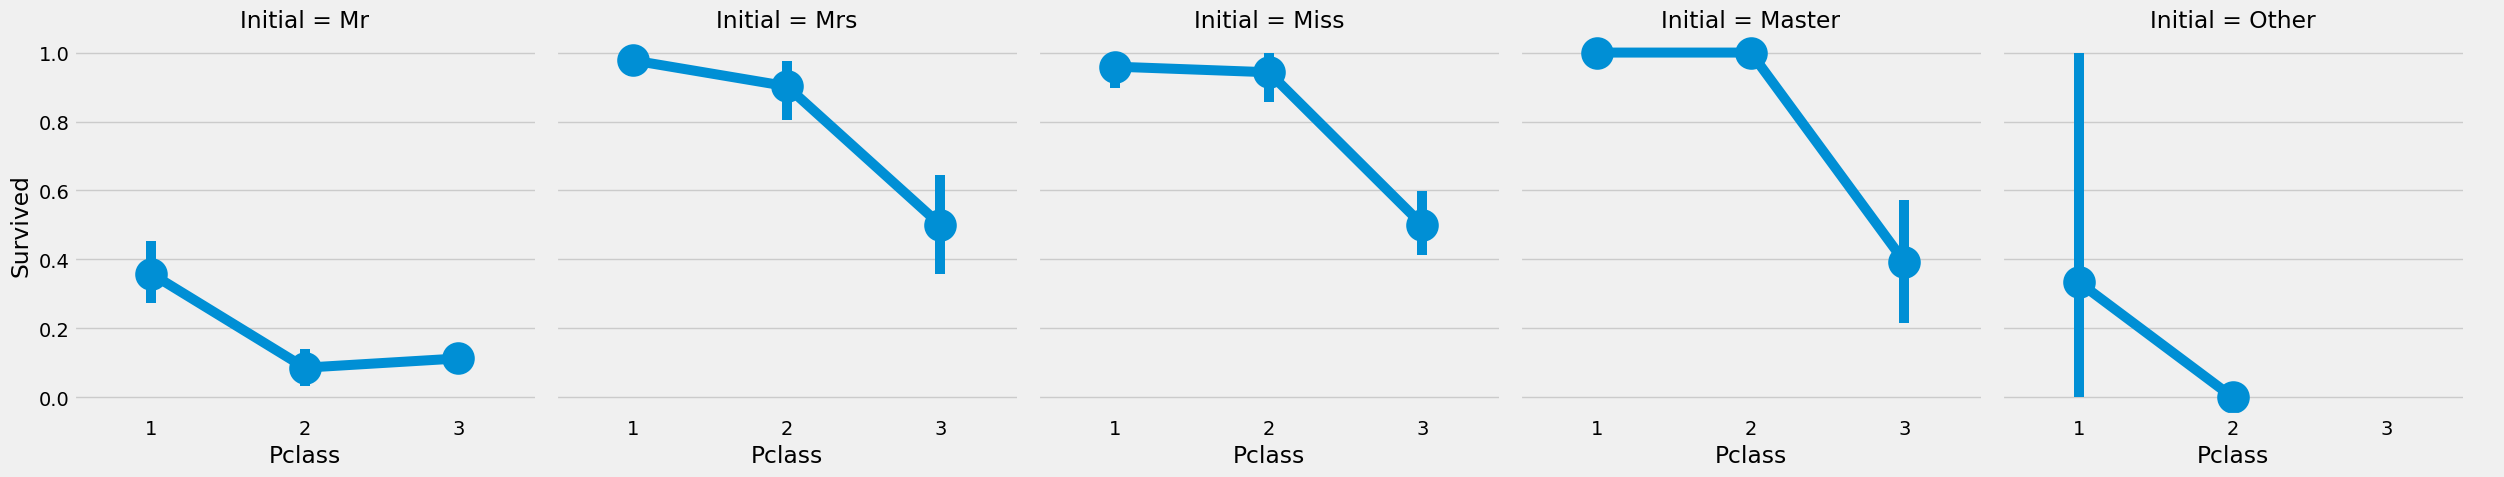

In [133]:
sns.catplot(x='Pclass',y='Survived',col='Initial',data=data, kind='point')
plt.show()

-> "여성과 아이 먼저(Women and Child First)"라는 구조 정책이 실제 데이터상에서도 사실임이 입증됨

### 4. Embarked--> Categorical Value

In [134]:
pd.crosstab([data.Embarked,data.Pclass],[data.Sex,data.Survived],margins=True).style.background_gradient(cmap='summer_r')

# Chances for Survival by Port Of Embarkation

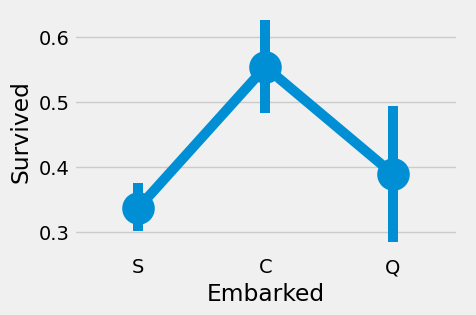

In [135]:
sns.catplot(x='Embarked',y='Survived',data=data, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

- 최고 생존율: C항구(Cherbourg)에서 승선한 승객들의 생존 확률이 약 0.55로 가장 높게 나타남.

- 최저 생존율: S항구(Southampton)에서 승선한 승객들의 생존 확률이 가장 낮게 측정됨.

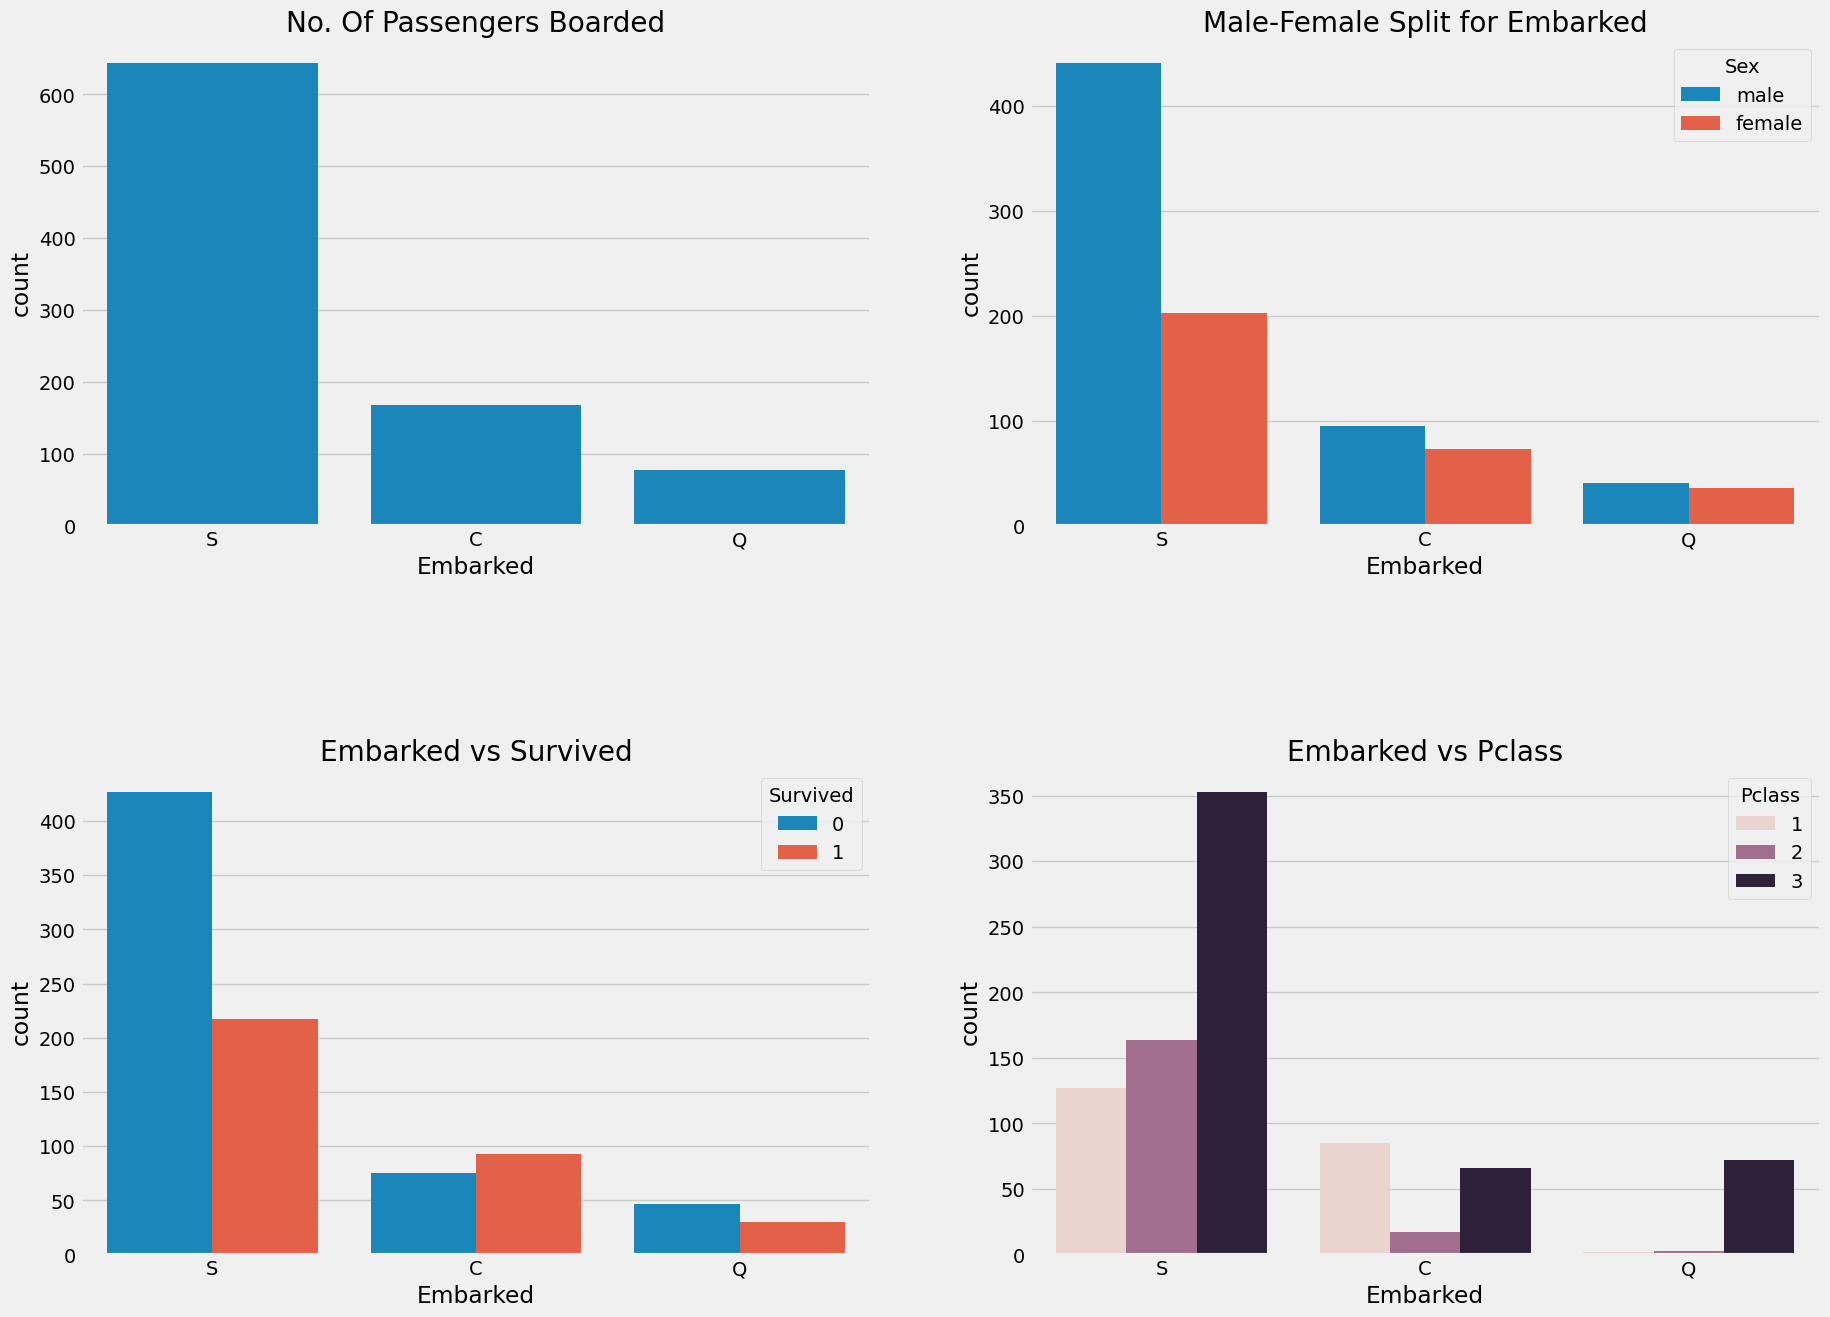

In [136]:
f,ax=plt.subplots(2,2,figsize=(20,15))
sns.countplot(x='Embarked',data=data,ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')
sns.countplot(x='Embarked',hue='Sex',data=data,ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')
sns.countplot(x='Embarked',hue='Survived',data=data,ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')
sns.countplot(x='Embarked',hue='Pclass',data=data,ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

- S항구 (Southampton): 가장 많은 승객이 탑승한 항구이며, 이들 중 대다수는 3등석(Pclass 3) 승객임.

- C항구 (Cherbourg): 높은 비율의 승객이 생존하여 운이 좋았던 것으로 보임. 그 이유는 해당 항구에서 탑승한 1등석 및 2등석 승객들이 대거 구조되었기 때문으로 추정됨.

- S항구의 특이점: 부유한 사람들(Rich people)이 가장 많이 탑승한 항구이기도 함에도 불구하고 생존율이 낮음. 이는 S항구에서 탑승한 3등석 승객의 약 81%가 생존하지 못했기 때문임.

- Q항구 (Queenstown): 탑승객의 약 95%가 3등석(Pclass 3) 승객으로 구성됨.

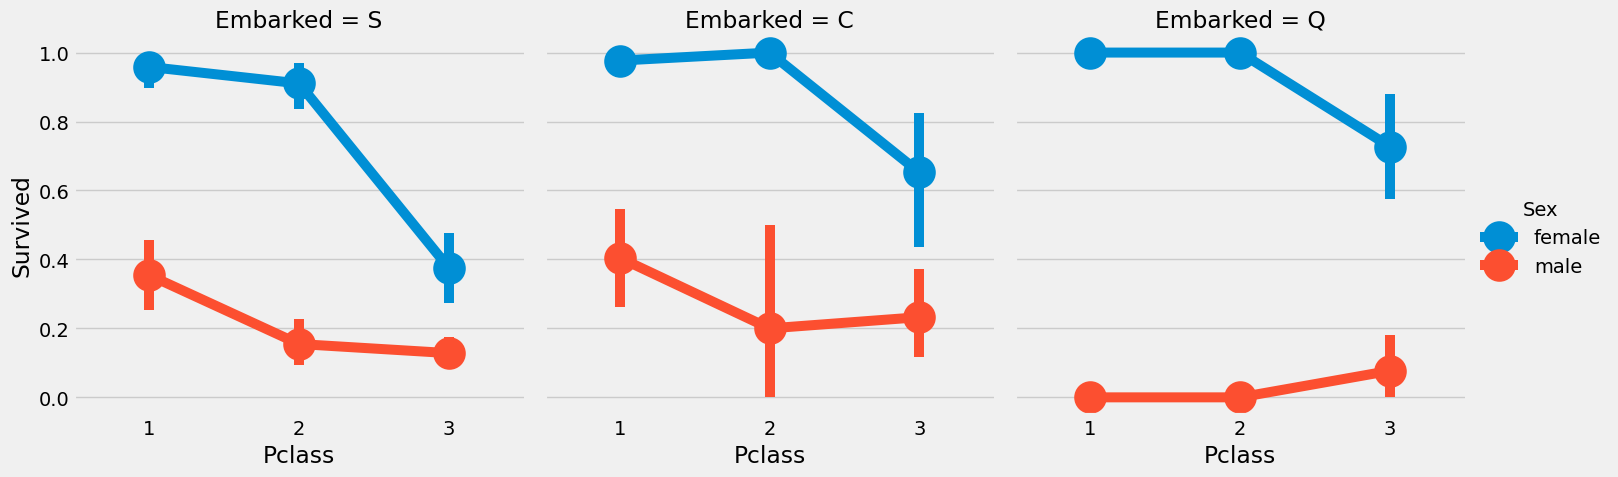

In [137]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',col='Embarked',data=data, kind='point')
plt.show()

- Pclass 1과 2에 탑승한 여성의 경우, 어떤 항구에서 탔는지와 관계없이 생존 확률이 거의 1(100%)에 수렴함.

- S항구에서 탑승한 3등석 승객들에게는 매우 가혹한 결과가 나타남. 남녀 모두 생존율이 매우 낮았으며, 이는 다시 한번 경제적 여유(Money Matters)가 생존과 직결되었음을 보여줌.

- Q항구는 남성들에게 가장 불운한 곳이었음. 탑승객 거의 전원이 3등석(Pclass 3)이었기 때문임.

# Filling Embarked NaN

In [138]:
data['Embarked'].fillna('S',inplace=True)

In [139]:
data.Embarked.isnull().any() #결측치 없음

np.False_

### 5. SibSip-->Discrete Feature

- SibSp : 해당 승객이 배에 혼자 탑승했는지, 아니면 가족 구성원과 함께 탑승했는지를 나타내는 지표

- Sibling (형제자매): 남동생, 여동생, 의붓형제, 의붓자매 포함.

- Spouse (배우자): 남편, 아내 (첩이나 약혼자는 제외).

In [140]:
pd.crosstab([data.SibSp],data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


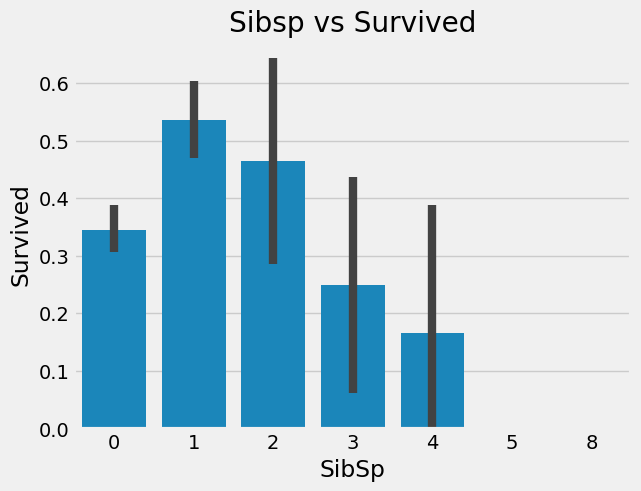

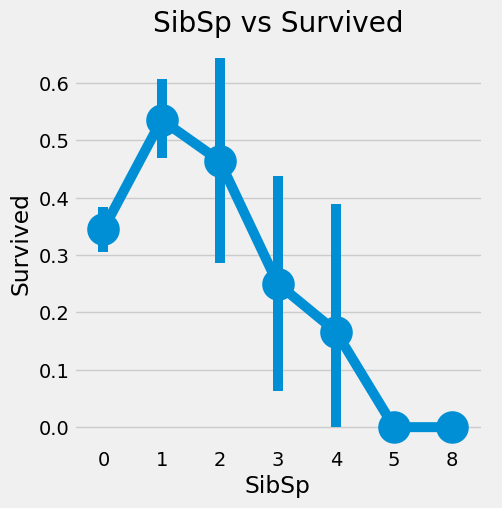

In [141]:
sns.barplot(x='SibSp',y='Survived',data=data)
plt.title('Sibsp vs Survived')
sns.catplot(x='SibSp',y='Survived',data=data, kind='point')
plt.title('SibSp vs Survived')
plt.show()

In [142]:
pd.crosstab(data.SibSp,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


- 나홀로 승객 (SibSp = 0): 생존율은 약 34.5%임.

- 가족 동반 시 경향: 동반한 형제자매/배우자 수가 늘어날수록 생존율은 대체로 감소하는 경향을 보임.

-> 심리적 요인: 본인의 생존보다 가족을 먼저 구하려는 경향이 반영되었을 것으로 추측됨.

- 대가족의 생존율 (SibSp 5~8): 놀랍게도 생존율이 0%로 나타남.

-> 대가족 생존율이 0%인 이유: Pclass와의 상관관계

결론: 3등석에 탑승한 4인 이상의 대가족은 전원 생존하지 못했음이 명백함. 이는 단순히 가족 수가 많아서라기보다, 3등석이라는 환경과 대가족이라는 조건이 결합된 결과로 풀이됨.

# Parch

In [143]:
pd.crosstab(data.Parch,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


-> SibSp 분석 때와 마찬가지로, 부모나 자녀를 많이 동반한 대가족(Larger Families)은 대부분 3등석(Pclass 3)에 집중되어 있음이 교차 도표(Crosstab)를 통해 재확인됨.

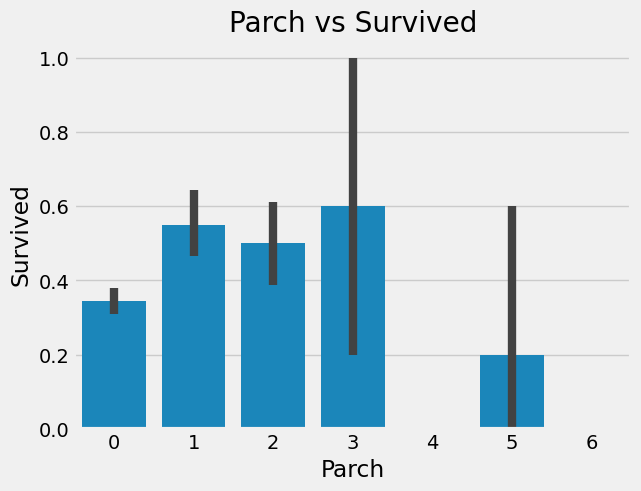

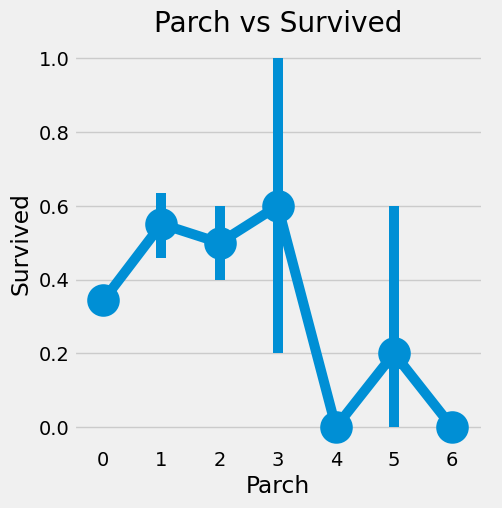

In [144]:
sns.barplot(x='Parch',y='Survived',data=data)
plt.title('Parch vs Survived')
sns.catplot(x='Parch',y='Survived',data=data, kind='point')
plt.title('Parch vs Survived')
plt.show()

- 생존 확률이 높은 경우 (1~3명): 배에 1~3명의 부모 또는 자녀와 함께 탑승한 승객은 생존 확률이 상대적으로 높게 나타납니다.

- 혼자 탑승한 경우 (0명): 가족 없이 혼자 탑승한 경우(Parch=0), 오히려 생존율이 낮아지는 경향을 보입니다 ("Being alone proves to be fatal").

- 대가족인 경우 (>4명): 함께 탄 부모/자녀가 4명 이상으로 늘어나면 생존 확률은 다시 급격히 감소합니다.

### 6. Fare--> Continous Feature

In [145]:
print('Highest Fare was:',data['Fare'].max())
print('Lowest Fare was:',data['Fare'].min())
print('Average Fare was:',data['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


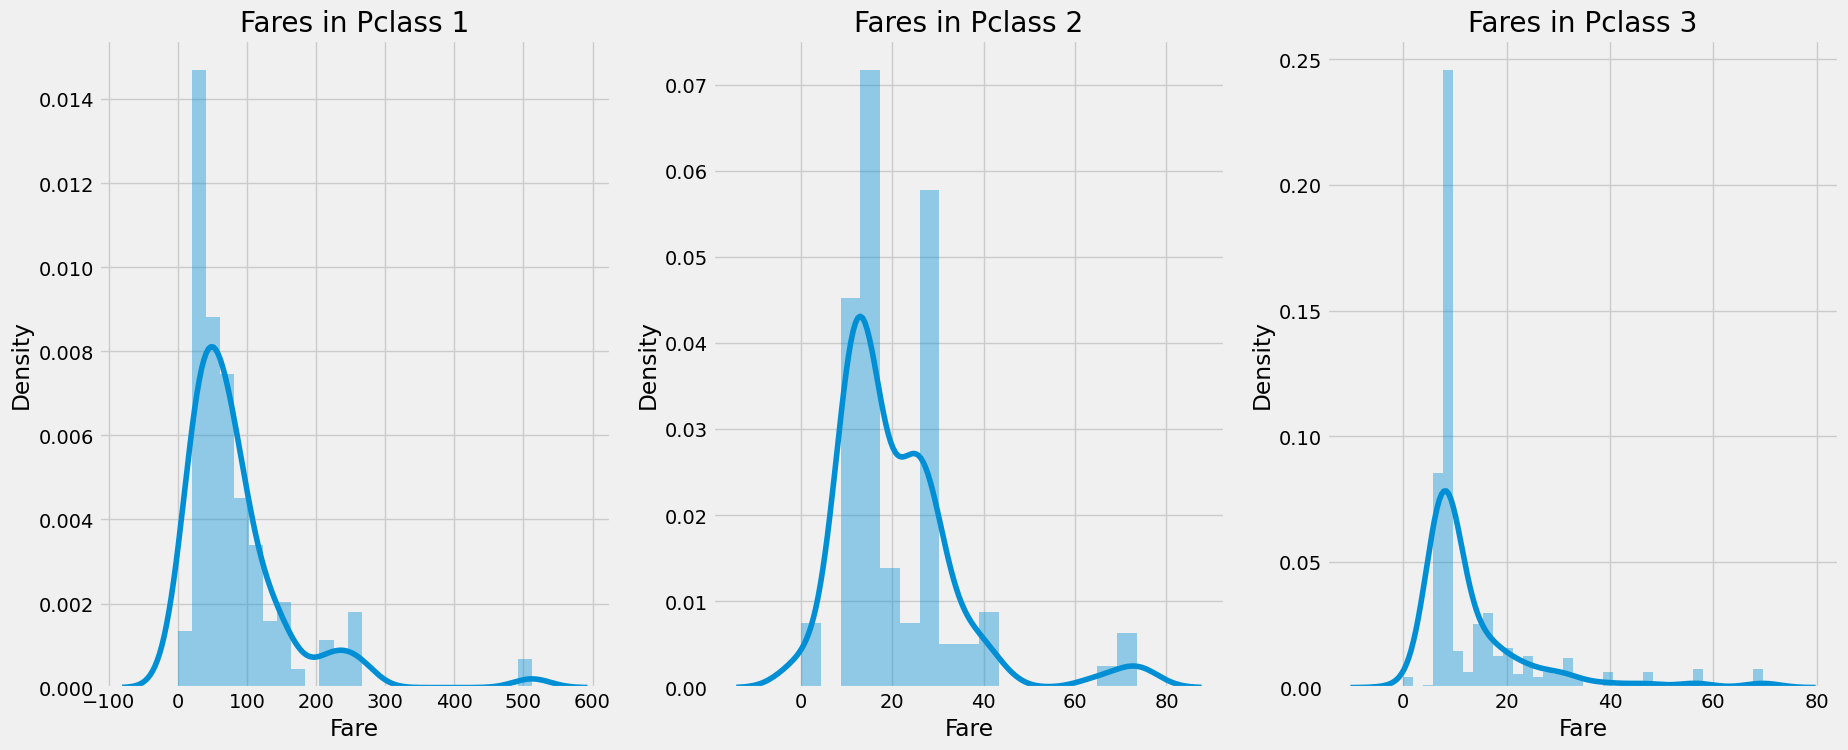

In [146]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.distplot(data[data['Pclass']==1].Fare,ax=ax[0])
ax[0].set_title('Fares in Pclass 1')
sns.distplot(data[data['Pclass']==2].Fare,ax=ax[1])
ax[1].set_title('Fares in Pclass 2')
sns.distplot(data[data['Pclass']==3].Fare,ax=ax[2])
ax[2].set_title('Fares in Pclass 3')
plt.show()

- Pclass1에서 높은 분포도가 나타남

# Observations in a Nutshell for all features:
- Sex: 여성에 대한 생존율이 더 높게 나타남
- Pclass: 1등석이 더 높은 생존율로 나타남
- Age: 5-10세 아이들이 생존율이 높게 나타나며 15-35세 나이가 가장 많이 사망함
- Embarked: C에 대한 생존율이 Pclass1에 S보다 더 나은 생존율을 보임
- Parch+Sibsp: 혼자일 때보다 가족과 함께인 아이가 더 높은 생존율을 보임

# Correlation Between The Features

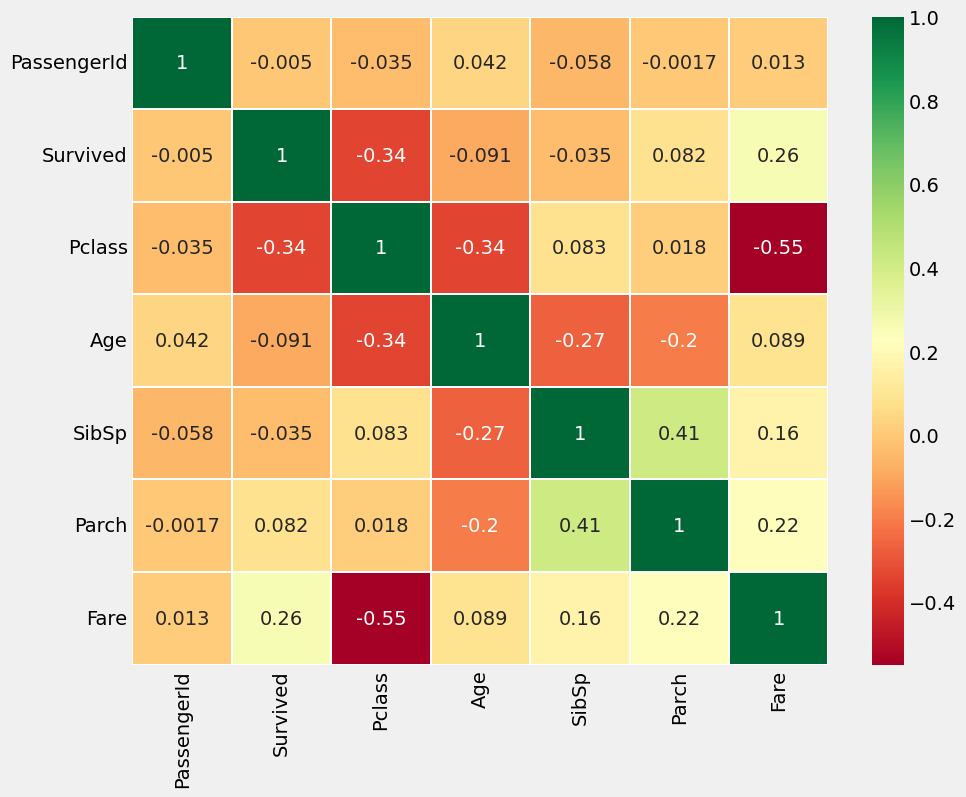

In [147]:
cols = ['PassengerId','Survived','Pclass','Age','SibSp','Parch','Fare']
sns.heatmap(data[cols].corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

1. 상관관계의 기본 원리

수치형 데이터 비교: 상관관계 분석은 숫자 데이터 사이에서만 가능하므로, 문자열 데이터는 분석 전 숫자로 인코딩되어야 함.

양의 상관관계 (Positive): 특성 A가 증가할 때 B도 함께 증가하는 관계 (최댓값 1).

음의 상관관계 (Negative): 특성 A가 증가할 때 B는 감소하는 관계 (최솟값 -1).

2. 다중공선성 (MultiCollinearity) 주의보

중복 정보 (Redundancy): 두 특성이 너무 높은 상관관계를 보이면, 사실상 같은 정보를 담고 있는 것

특성 제거의 필요성: 중복된 특성은 모델의 학습 시간을 늘리고 성능에 악영향을 줄 수 있으므로, 하나를 제거하는 것이 유리함.

3. 타이타닉 데이터의 특징

분석 결과: 히트맵 확인 결과, 특성들 간의 상관관계가 전반적으로 낮게 나타남.

최고 상관관계: SibSp(형제/배우자)와 Parch(부모/자녀) 사이의 관계가 0.41로 가장 높았으나, 이는 모델에서 제외할 만큼 치명적인 수준은 아님.

# Part2: Feature Engineering and Data Cleaning

특성 공학(Feature Engineering)

1. 특성 선택 및 제거 (Feature Selection & Elimination)
불필요한 정보 제거: 모든 특성이 예측에 도움이 되는 것은 아님

중복 제거: 앞서 상관관계 분석에서 보았듯이, 서로 너무 유사한 정보를 담고 있는 중복(Redundant) 특성을 제거하여 모델의 복잡도를 낮추고 학습 속도를 높임

2. 새로운 특성 생성 (Feature Extraction & Creation)
숨겨진 정보 발굴: 기존 특성을 조합하거나 분리하여 새로운 의미를 부여

예시: Name에서 Initial(호칭)을 추출한 것과 같으며 이는 단순한 문자열이었던 이름을 '사회적 지위'나 '연령대'라는 유의미한 수치로 변환한 륭한 사례

또 다른 예: SibSp + Parch = FamilySize (가족 총합)

3. 데이터 변환 (Feature Transformation)
모델 최적화: 알고리즘이 이해하기 쉬운 형태로 데이터를 변환

예시: * Binning: 연속형 변수인 Fare(요금)나 Age(연령)를 특정 구간(0, 1, 2...)으로 나누는 것.

Encoding: 문자열(남성, 여성)을 숫자(0, 1)로 바꾸는 것.

# Age_band


1. 연속형 변수의 문제점
- 데이터의 파편화
- 비교의 어려움

2. 해결책
- 데이터 빈닝 (Binning): 연속적인 수치들을 일정한 간격으로 묶어 하나의 '바구니(Bin)'에 담는 과정
- 효과: "21세"와 "22세"라는 개별 데이터 대신 "16~32세 사이의 청년층"이라는 범주(Category)로 단순화하여 모델이 생존 패턴을 더 명확하게 학습하게 함

3. 구간 설정 전략 (The Strategy)- 최댓값 기준: 최고령 승객이 80세이므로, 이를 5개의 구간으로 나눔
- 구간 크기: $80 \div 5 = 16$. 따라서 한 구간의 크기는 16세가 됨

In [148]:
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2


In [149]:
data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')

,count
Age_band,
1,382
2,325
0,104
3,69
4,11


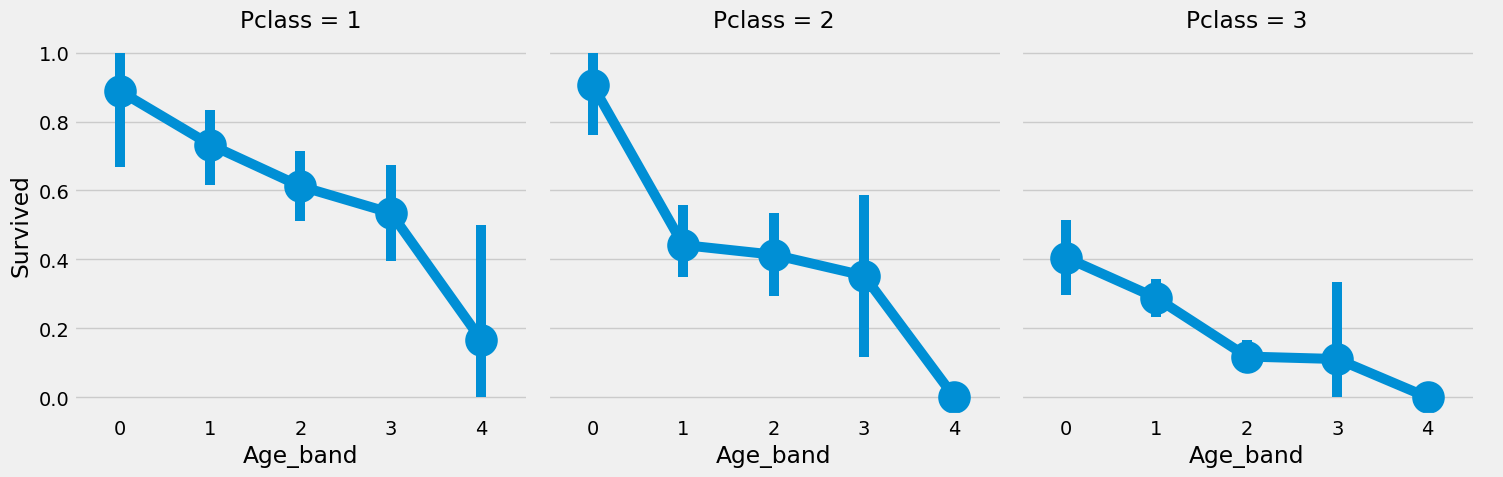

In [150]:
sns.catplot(x='Age_band',y='Survived',data=data, col='Pclass', kind='point')
plt.show()

# Family_Size and Alone

1. Family_size (가족 규모)

- 생성 방법: SibSp (형제/배우자) + Parch (부모/자녀) + 1 (본인)

- 단순히 누가 탔느냐보다 "총 몇 명이 함께 행동했는가"가 구조 우선순위나 탈출 속도에 어떤 영향을 미쳤는지 확인하기 위함. 본인을 포함하기 위해 보통 1을 더한다.

2. Alone (독신 여부)

- 생성 방법: Family_size가 1이면 Alone = 1 (True), 그 이상이면 0 (False).

- "가족이 한 명이라도 있는 그룹"과 "완전히 혼자인 그룹" 사이의 생존율 차이를 극명하게 비교하기 위함

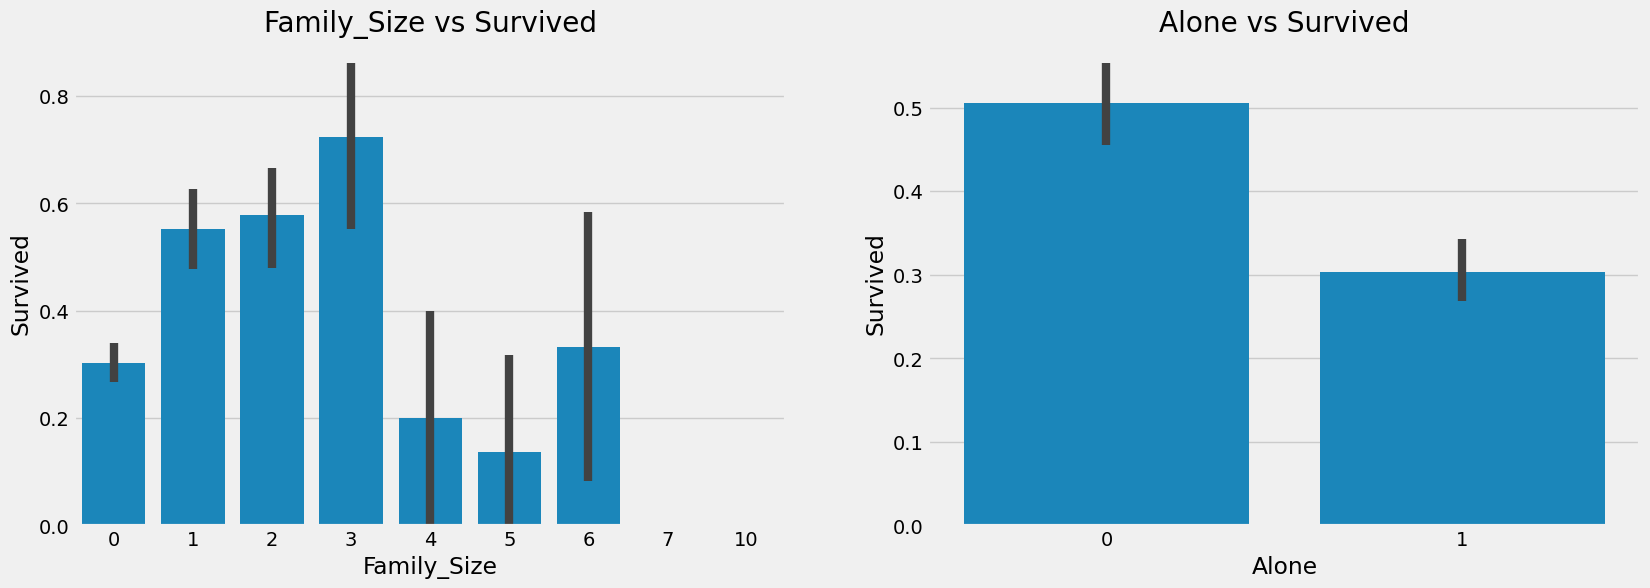

In [151]:
data['Family_Size']=0
data['Family_Size']=data['Parch']+data['SibSp']
data['Alone']=0
data.loc[data.Family_Size==0, 'Alone']=1

f,ax=plt.subplots(1,2,figsize=(18,6))
sns.barplot(x='Family_Size',y='Survived',data=data,ax=ax[0])
ax[0].set_title('Family_Size vs Survived')
sns.barplot(x='Alone',y='Survived',data=data,ax=ax[1])
ax[1].set_title('Alone vs Survived')
plt.close(2)
plt.close(3)
plt.show()

1. 나홀로 승객 (Family_Size = 0, Alone)

현상: 생존 확률이 매우 낮음.

이유: 위급 상황에서 정보를 공유하거나 구조를 도와줄 동료가 없으며, 심리적인 위축이 생존에 부정적인 영향을 미쳤을 가능성이 큼.

2. 적정 규모의 가족 (Family_Size 1 ~ 3)

현상: 생존율이 가장 높음.

이유: 서로를 챙길 수 있는 최소한의 단위이면서, 동시에 대피 시 기동성을 유지할 수 있는 최적의 규모임.

3. 대가족 (Family_Size > 4)

현상: 가족 수가 늘어날수록 생존율이 다시 급격히 감소함.

이유: 모든 가족 구성원을 다 찾아서 함께 이동하려다 탈출 골든타임을 놓치기 쉬움. 또한, 앞서 분석했듯 대가족은 주로 탈출이 불리한 3등석(Pclass 3)에 밀집되어 있었음.

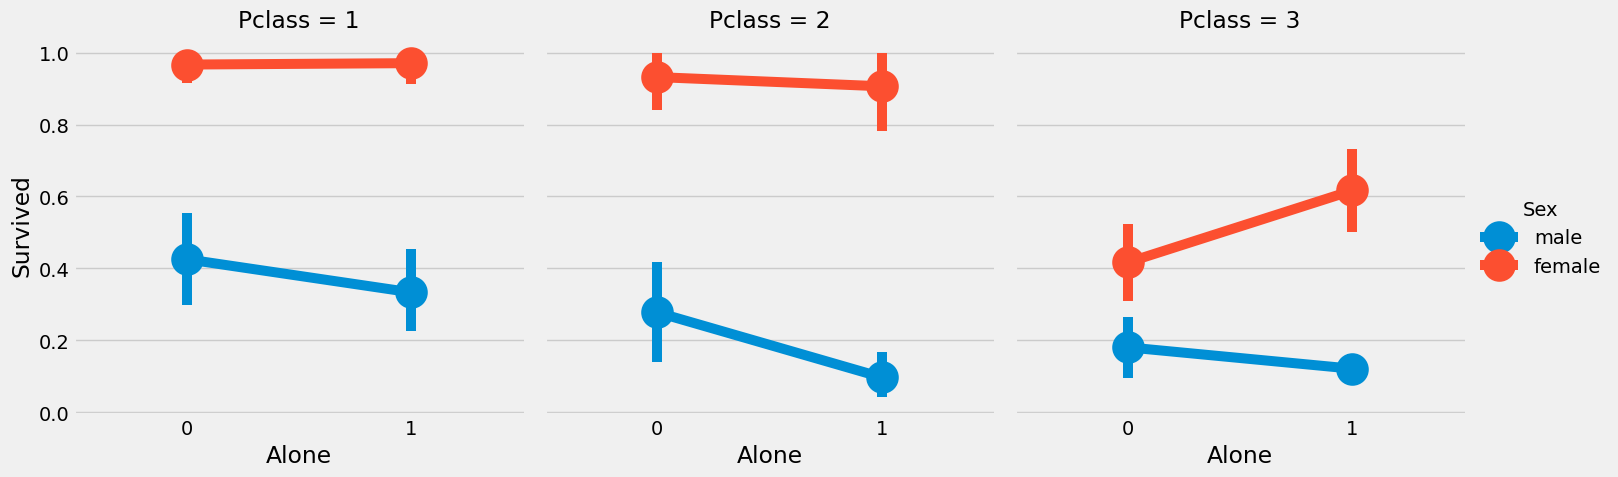

In [152]:
sns.catplot(x='Alone',y='Survived',data=data,hue='Sex',col='Pclass', kind='point')
plt.show()

-> 혼자 탑승한 승객은 구조 요청이 어려워 생존율이 낮지만 Pclass3에서는 다르게 나타남

# Fare_Range
1. pd.qcut

- 데이터 불균형 해결: 타이타닉의 요금 데이터는 저가 티켓에 승객이 압도적으로 몰려 있는 편향된(Skewed) 분포를 가짐

- 균등 분할: 단순히 값의 범위를 나누는 pd.cut과 달리, pd.qcut은 각 구간에 들어가는 데이터의 개수(빈도)가 동일하도록 구간을 나눔

- 효과: 모델이 모든 구간(저가, 중저가, 중고가, 고가 등)에 대해 충분한 데이터를 학습할 수 있게 하여 학습 효율을 높임

2. 작동 원리 (5개 구간 예시)

- 전체 승객을 요금 순으로 세운다

- 상위 20%씩 끊어서 총 5개의 그룹으로 만든다

- 각 그룹에 0, 1, 2, 3, 4와 같은 순서형(Ordinal) 값을 부여한다

In [153]:
data['Fare_Range']=pd.qcut(data['Fare'],4)
data.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


-> 요금 구간율이 높아질 수록 생존율이 뚜렷하게 상승하는 경향을 보임

In [154]:
data['Fare_cat']=0
data.loc[data['Fare']<=7.91, 'Fare_cat']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454),'Fare_cat']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31),'Fare_cat']=2
data.loc[(data['Fare']>31)&(data['Fare']<=513),'Fare_cat']=3

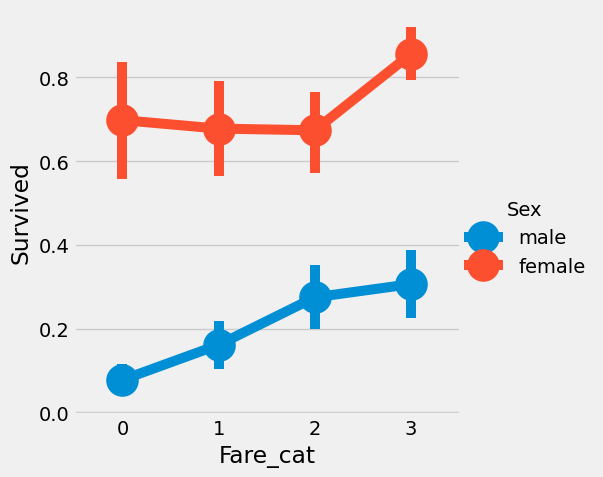

In [155]:
sns.catplot(x='Fare_cat',y='Survived',data=data,hue='Sex', kind='point')
plt.show()

# Converting String Values into Numeric

In [156]:
data['Sex'].replace(['male', 'female'],[0,1],inplace=True)
data['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
data['Initial'].replace(['Mr','Mrs','Miss','Master','Other'],[0,1,2,3,4],inplace=True)

Drop 대상
1. Name: 범주형으로 변환할 수 없는 단순 문자열 (Initial로 대체됨)

2. Age: 연속형 변수라 모델 학습에 부적합 (Age_band로 대체됨)

3. Ticket: 규칙이 없는 임의의 문자열이라 분류가 불가능

4. Fare: 연속형 변수 (Fare_cat으로 대체됨)

5. Cabin: 결측치가 너무 많고(NaN), 한 사람이 여러 객실을 가진 경우도 있어 정보 가치가 낮음

6. Fare_Range: Fare_cat을 만들기 위한 중간 단계이므로 더 이상 필요 없음

7. PassengerId: 승객 식별용 번호일 뿐, 생존 여부와는 상관이 없음

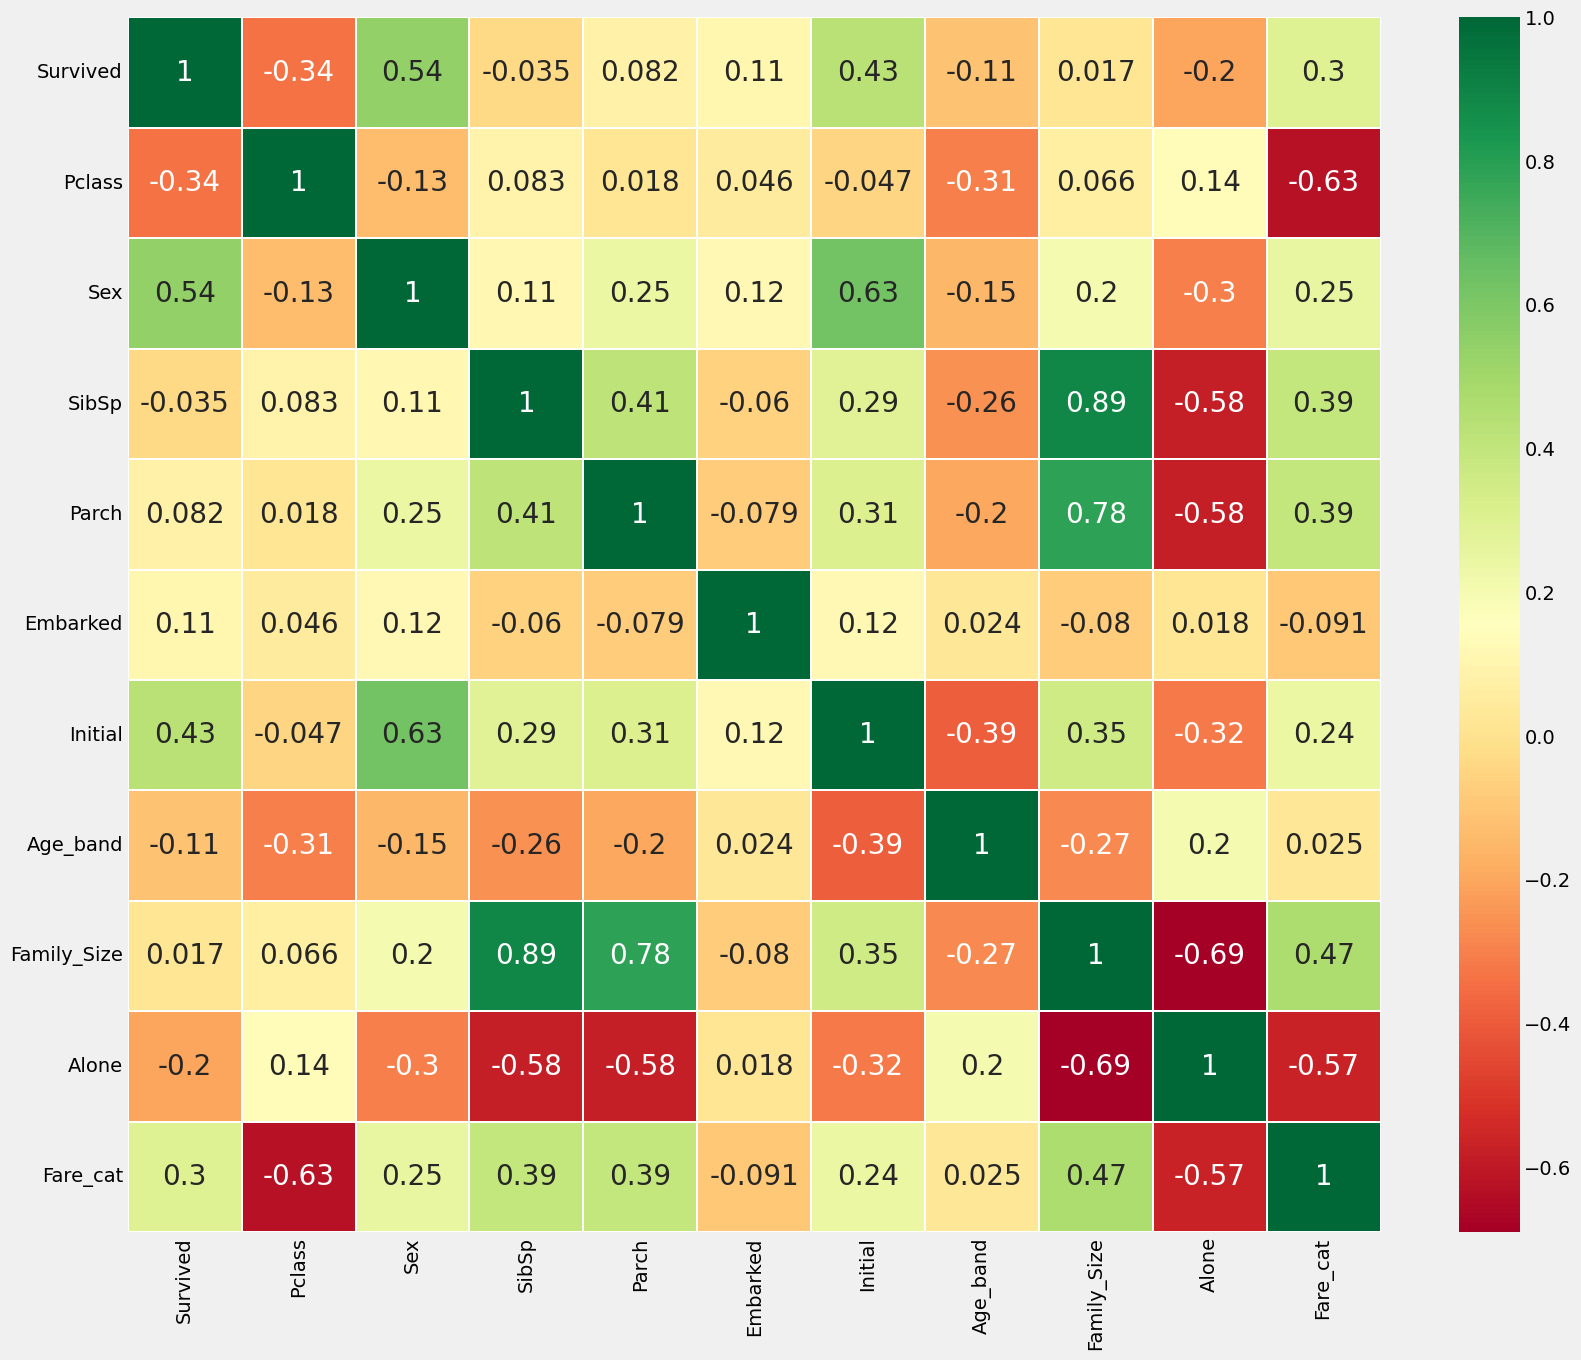

In [157]:
data.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'],axis=1,inplace=True)
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':20})
fig=plt.gcf()
fig.set_size_inches(18,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# Part3: Predictive Modeling

알고리즘 리스트 및 특징
1. Logistic Regression (로지스틱 회귀)

2. Support Vector Machines (SVM)

- Linear

- Radial (RBF)

3. Random Forest (랜덤 포레스트)

4. K-Nearest Neighbours (KNN)

5. Naive Bayes (나이브 베이즈)

6. Decision Tree (결정 트리)

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix

In [159]:
train,test=train_test_split(data,test_size=0.3,random_state=0,stratify=data['Survived'])
train_X=train[train.columns[1:]]
train_Y=train[train.columns[:1]]
test_X=test[test.columns[1:]]
test_Y=test[test.columns[:1]]
X=data[data.columns[1:]]
Y=data['Survived']

In [160]:
#Radial Support Vector Machines(rbf-SVM)
model=svm.SVC(kernel='rbf',C=1,gamma=0.1)
model.fit(train_X,train_Y)
prediction1=model.predict(test_X)
print('Accuracy for rbf SVM is ',metrics.accuracy_score(prediction1,test_Y))

Accuracy for rbf SVM is  0.835820895522388


In [161]:
#Linear Support Vector Machine(linear_SVM)
model=svm.SVC(kernel='linear',C=0.1,gamma=0.1)
model.fit(train_X,train_Y)
prediction2=model.predict(test_X)
print('Accuracy for linear SVM is',metrics.accuracy_score(prediction2,test_Y))

Accuracy for linear SVM is 0.8171641791044776


In [162]:
#Logistic Regression
model = LogisticRegression()
model.fit(train_X,train_Y)
prediction3=model.predict(test_X)
print('The accuracy of the Logistic Regression is',metrics.accuracy_score(prediction3,test_Y))

The accuracy of the Logistic Regression is 0.8134328358208955


In [163]:
#Decision Tree
model=DecisionTreeClassifier()
model.fit(train_X,train_Y)
prediction4=model.predict(test_X)
print('The accuracy of the Decision Tree is',metrics.accuracy_score(prediction4,test_Y))

The accuracy of the Decision Tree is 0.7985074626865671


In [164]:
#K-Nearest Neighbors(KNN)
model=KNeighborsClassifier()
model.fit(train_X,train_Y)
prediction5=model.predict(test_X)
print('The accuracy of the KNN is',metrics.accuracy_score(prediction5,test_Y))

The accuracy of the KNN is 0.8134328358208955


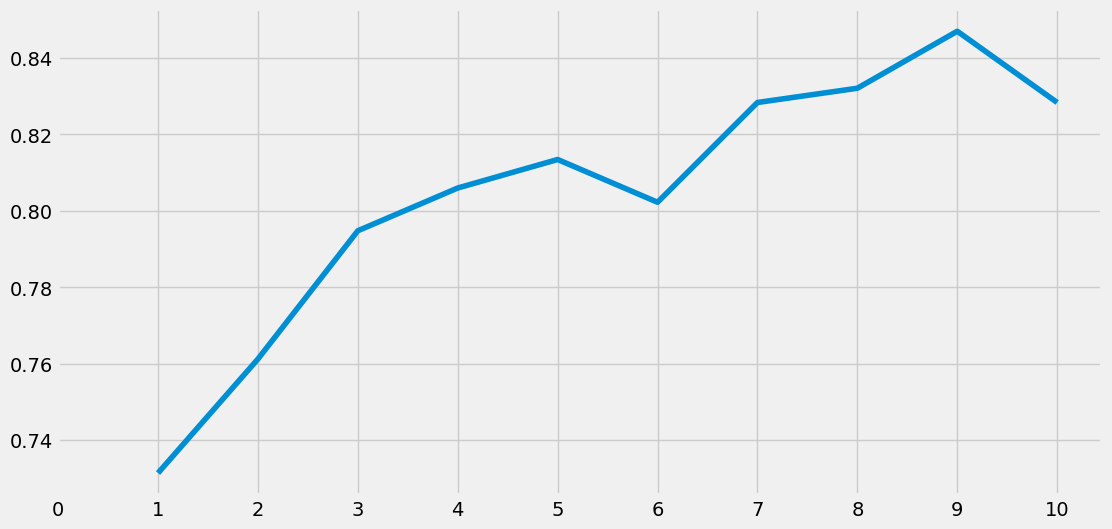

Accuracies for different values of n are: [0.73134328 0.76119403 0.79477612 0.80597015 0.81343284 0.80223881
 0.82835821 0.83208955 0.84701493 0.82835821] with the max value as  0.8470149253731343


In [165]:
#KNN 모델의 핵심 파라미터인 n_neighbors 값에 따른 성능 변화
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
  model=KNeighborsClassifier(n_neighbors=i)
  model.fit(train_X,train_Y)
  prediction=model.predict(test_X)
  a = pd.concat([a, pd.Series([metrics.accuracy_score(prediction, test_Y)])], ignore_index=True)

plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

In [166]:
#Gaussian Naive Bayes
model=GaussianNB()
model.fit(train_X, train_Y)
prediction6=model.predict(test_X)
print('The accuracy of the NaiveBayes is', metrics.accuracy_score(prediction6,test_Y))

The accuracy of the NaiveBayes is 0.8134328358208955


In [167]:
#Random Forests
model=RandomForestClassifier(n_estimators=100)
model.fit(train_X, train_Y)
prediction7=model.predict(test_X)
print('The accuracy of the Random Forests is',metrics.accuracy_score(prediction7,test_Y))

The accuracy of the Random Forests is 0.8246268656716418


- model variance: Training data와 Testing data의 변화에 따라 정확도가 달라지는 것

# Cross Validation

1. 모델 분산(Model Variance) 해결: 훈련 데이터의 구성에 따라 정확도가 널뛰는 현상을 줄여줌

2. 일반화(Generalization): 데이터셋의 모든 부분을 한 번씩은 검증용으로 사용하기 때문에, 모델이 특정 데이터에만 최적화(과적합)되는 것을 막아줌

3. 불균형 데이터 대응: 모든 인스턴스를 학습과 검증에 고루 사용하므로, 특정 클래스가 적은 상황에서도 더 신뢰할 수 있는 평균 성능을 얻을 수 있



In [168]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
kfold = KFold(n_splits=10, shuffle=True, random_state=22)
xyz=[]
accuracy=[]
std=[]
classifiers=['Linear Svm','Radial Svm','Logistic Regression','KNN','Decision Tree','Naive Bayes','Random Forest']
models=[svm.SVC(kernel='linear'),svm.SVC(kernel='rbf'),LogisticRegression(),KNeighborsClassifier(n_neighbors=9),DecisionTreeClassifier(),GaussianNB(),RandomForestClassifier(n_estimators=100)]
for i in models:
  model = i
  cv_result = cross_val_score(model,X,Y,cv=kfold,scoring='accuracy')
  cv_result=cv_result
  xyz.append(cv_result.mean())
  std.append(cv_result.std())
  accuracy.append(cv_result)
new_models_dataframe2=pd.DataFrame({'CV Mean':xyz,'Std':std},index=classifiers)
new_models_dataframe2

,CV Mean,Std
Linear Svm,0.784607,0.057841
Radial Svm,0.828377,0.057096
Logistic Regression,0.799176,0.040154
KNN,0.808140,0.035630
Decision Tree,0.804744,0.044561
Naive Bayes,0.795843,0.054861
Random Forest,0.815968,0.051163


<Axes: >

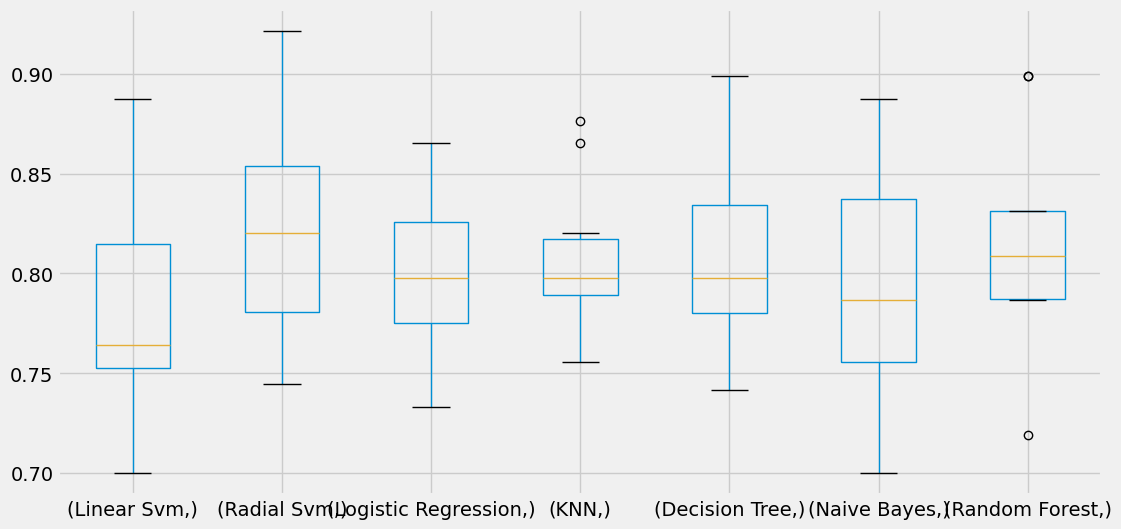

In [169]:
plt.subplots(figsize=(12,6))
box=pd.DataFrame(accuracy,index=[classifiers])
box.T.boxplot()

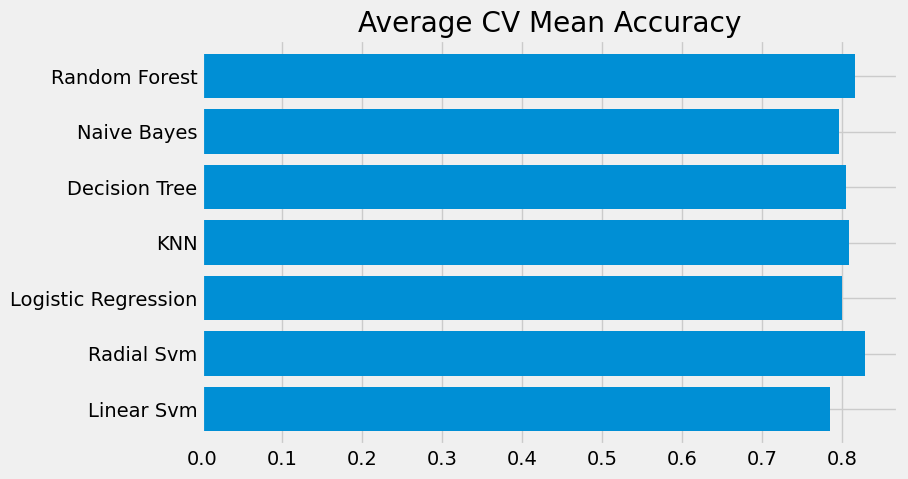

In [170]:
new_models_dataframe2['CV Mean'].plot.barh(width=0.8)
plt.title('Average CV Mean Accuracy')
fig=plt.gcf()
fig.set_size_inches(8,5)
plt.show()

# Confusion Matrix

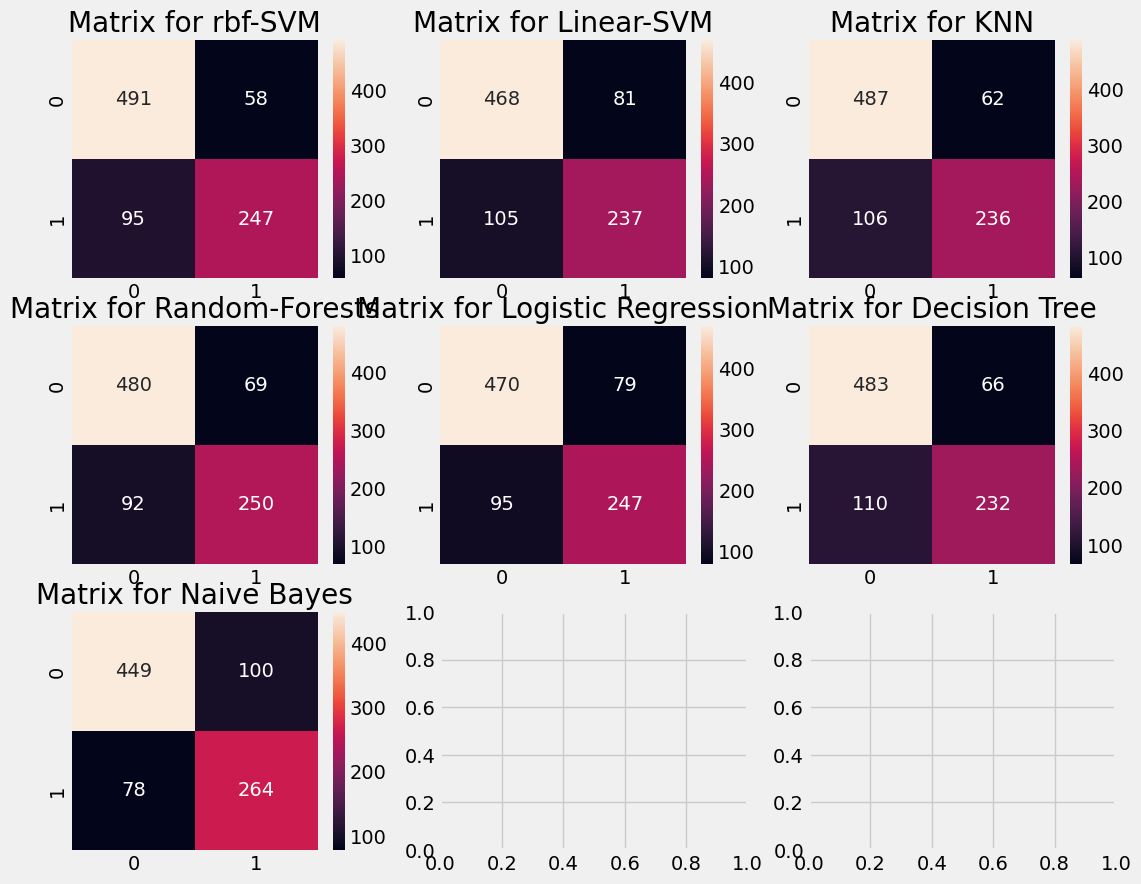

In [172]:
f,ax=plt.subplots(3,3,figsize=(12,10))
y_pred = cross_val_predict(svm.SVC(kernel='rbf'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,0],annot=True,fmt='2.0f')
ax[0,0].set_title('Matrix for rbf-SVM')
y_pred = cross_val_predict(svm.SVC(kernel='linear'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,1],annot=True,fmt='2.0f')
ax[0,1].set_title('Matrix for Linear-SVM')
y_pred = cross_val_predict(KNeighborsClassifier(n_neighbors=9),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,2],annot=True,fmt='2.0f')
ax[0,2].set_title('Matrix for KNN')
y_pred = cross_val_predict(RandomForestClassifier(n_estimators=100),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,0],annot=True,fmt='2.0f')
ax[1,0].set_title('Matrix for Random-Forests')
y_pred = cross_val_predict(LogisticRegression(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,1],annot=True,fmt='2.0f')
ax[1,1].set_title('Matrix for Logistic Regression')
y_pred = cross_val_predict(DecisionTreeClassifier(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,2],annot=True,fmt='2.0f')
ax[1,2].set_title('Matrix for Decision Tree')
y_pred = cross_val_predict(GaussianNB(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[2,0],annot=True,fmt='2.0f')
ax[2,0].set_title('Matrix for Naive Bayes')
plt.subplots_adjust(hspace=0.2,wspace=0.2)
plt.show()

혼동 행렬 분석 핵심 요약 (음체 버전)
1. rbf-SVM의 특징

사망자(0) 예측에 아주 강함. (491명 정답)

근데 생존자를 사망자로 잘못 판단하는 경우가 95건으로 꽤 많음.

즉, "보수적인 모델"이라고 볼 수 있음. (웬만하면 죽었다고 판단함)

2. Naive Bayes의 특징

생존자(1)를 찾아내는 능력이 rbf-SVM보다 뛰어남.

즉, "희망적인 모델"임. (생존 가능성을 더 적극적으로 열어둠)

하이퍼 파라미터 튜닝

1. SVM 하이퍼파라미터 튜닝
- SVM에서는 C(오차에 대한 관대함)와 gamma(결정 경계의 곡률) 값이 핵심임.

2. Random Forest 하이퍼파라미터 튜닝
- 랜덤 포레스트는 n_estimators(만들 나무의 개수)가 가장 중요함.



In [173]:
#SVM
from sklearn.model_selection import GridSearchCV
C=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
gamma=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
kernel=['rbf','linear']
hyper={'kernel':kernel,'C':C,'gamma':gamma}
gd=GridSearchCV(estimator=svm.SVC(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
0.8282593685267716
SVC(C=0.4, gamma=0.3)


In [174]:
#Random Forests
n_estimators=range(100,1000,100)
hyper={'n_estimators':n_estimators}
gd=GridSearchCV(estimator=RandomForestClassifier(random_state=0),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
0.819327098110602
RandomForestClassifier(n_estimators=300, random_state=0)


# Ensembling
1. Voting Classifier (투표 분류기)
- 가장 직관적인 방법임. 여러 개의 서로 다른 모델(SVM, Logistic Regression, KNN 등)을 만든 다음, 각 모델이 내놓은 결과 중 가장 많이 나온 답을 최종 결과로 선택하는 방식임.

Hard Voting: 단순 다수결 (2명이 '생존', 1명이 '사망'이라고 하면 '생존'으로 결정)

Soft Voting: 각 모델이 예측한 확률들의 평균을 내서 결정 (이게 보통 성능이 더 좋음)

2. Bagging (Bootstrap Aggregating)
- 같은 알고리즘을 사용하지만, 데이터셋을 무작위로 다르게 샘플링해서 여러 모델을 만드는 방식임.

가장 대표적인 예가 바로 우리가 썼던 Random Forest임.

분산(Variance)을 줄여서 과적합을 방지하는 데 특효약임.

3. Boosting
- 여러 모델을 만들긴 하는데, 앞선 모델이 틀린 문제를 다음 모델이 집중적으로 학습하도록 가중치를 주는 방식임.

AdaBoost, Gradient Boosting (XGBoost, LightGBM) 등이 여기 속함.

정확도를 끌어올리는 데는 최강이지만, 잘못하면 노이즈까지 학습할 위험이 있음.

In [175]:
#Voting Classifier
from sklearn.ensemble import VotingClassifier
ensemble_lin_rbf=VotingClassifier(estimators=[('KNN',KNeighborsClassifier(n_neighbors=10)),
                                              ('RBF',svm.SVC(probability=True,kernel='rbf',C=0.5,gamma=0.1)),
                                              ('RFor',RandomForestClassifier(n_estimators=500,random_state=0)),
                                              ('LR',LogisticRegression(C=0.05)),
                                              ('DT',DecisionTreeClassifier(random_state=0)),
                                              ('NB',GaussianNB()),
                                              ('svm',svm.SVC(kernel='linear',probability=True))
                                             ],
                       voting='soft').fit(train_X,train_Y)
print('The accuracy for ensembled model is:',ensemble_lin_rbf.score(test_X,test_Y))
cross=cross_val_score(ensemble_lin_rbf,X,Y, cv = 10,scoring = "accuracy")
print('The cross validated score is',cross.mean())

The accuracy for ensembled model is: 0.8208955223880597
The cross validated score is 0.8249188514357053


# Bagging


In [178]:
#Bagged KNN
from sklearn.ensemble import BaggingClassifier
model=BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=3),random_state=0,n_estimators=700)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged KNN is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged KNN is:',result.mean())

The accuracy for bagged KNN is: 0.832089552238806
The cross validated score for bagged KNN is: 0.8104244694132333


In [180]:
#Bagged DecisionTree
model=BaggingClassifier(estimator=DecisionTreeClassifier(),random_state=0,n_estimators=100)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged Decision Tree is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged Decision Tree is:',result.mean())

The accuracy for bagged Decision Tree is: 0.8208955223880597
The cross validated score for bagged Decision Tree is: 0.8171410736579275


# Boosting

In [181]:
#AdaBoost(Adaptive Boosting)
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.1)
result=cross_val_score(ada,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for AdaBoost is:',result.mean())

The cross validated score for AdaBoost is: 0.8136828963795256


In [182]:
#Stochastic Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
grad=GradientBoostingClassifier(n_estimators=500,random_state=0,learning_rate=0.1)
result=cross_val_score(grad,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for Gradient Boosting is:',result.mean())

The cross validated score for Gradient Boosting is: 0.8115230961298376


In [186]:
#XGBoost
import xgboost as xg
xgboost=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
result=cross_val_score(xgboost,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for XGBoost is:',result.mean())

The cross validated score for XGBoost is: 0.8182771535580524


In [187]:
#Hyper-Parameter Tuning for AdaBoost
n_estimators=list(range(100,1100,100))
learn_rate=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
hyper={'n_estimators':n_estimators,'learning_rate':learn_rate}
gd=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
0.8293892411022534
AdaBoostClassifier(learning_rate=0.4, n_estimators=800)


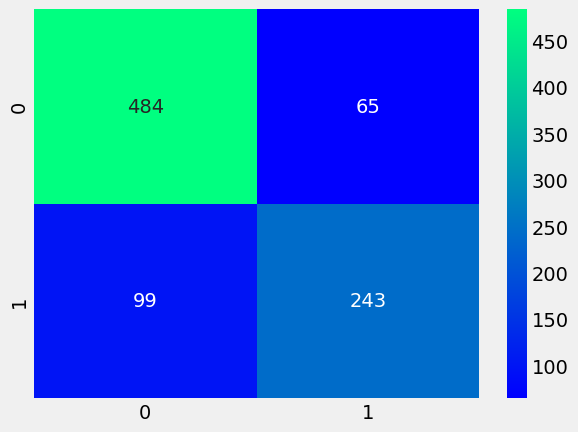

In [189]:
#Confusion Matrix for the Best Model
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.05)
result=cross_val_predict(ada,X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,result),cmap='winter',annot=True,fmt='2.0f')
plt.show()

# Feature Importance

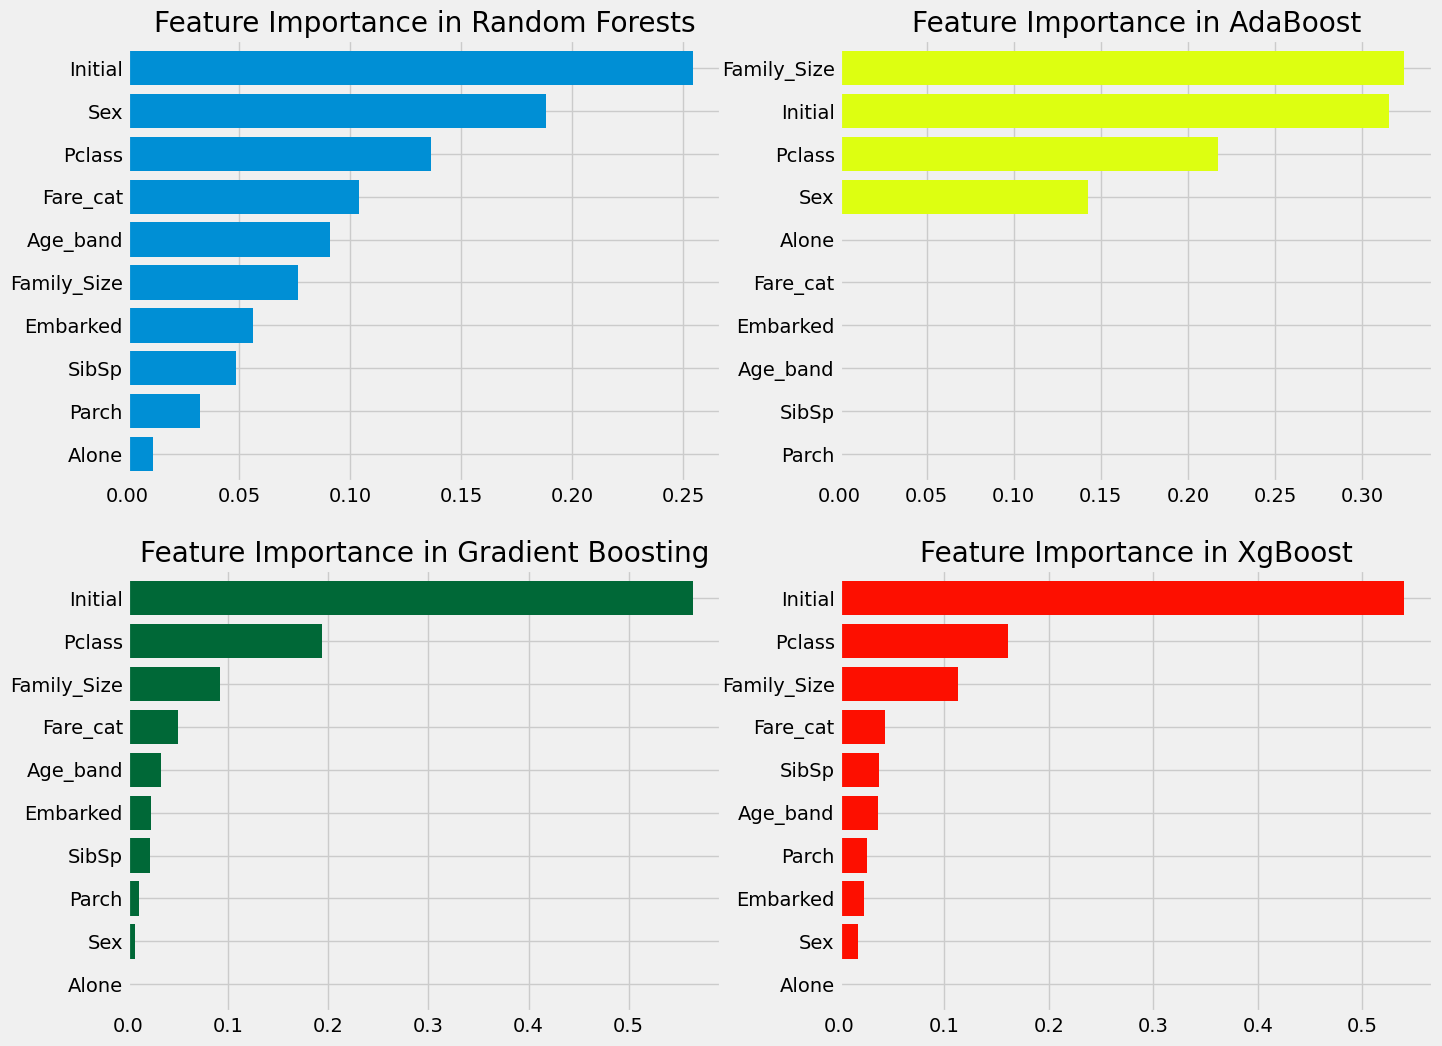

In [190]:
f,ax=plt.subplots(2,2,figsize=(15,12))
model=RandomForestClassifier(n_estimators=500,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,0])
ax[0,0].set_title('Feature Importance in Random Forests')
model=AdaBoostClassifier(n_estimators=200,learning_rate=0.05,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,1],color='#ddff11')
ax[0,1].set_title('Feature Importance in AdaBoost')
model=GradientBoostingClassifier(n_estimators=500,learning_rate=0.1,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,0],cmap='RdYlGn_r')
ax[1,0].set_title('Feature Importance in Gradient Boosting')
model=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,1],color='#FD0F00')
ax[1,1].set_title('Feature Importance in XgBoost')
plt.show()


1. Sex가 안 보이고 Initial이 높은 이유

상관관계의 마법: 우리가 이름에서 추출한 Initial(Mr, Mrs, Miss 등) 안에는 이미 성별 정보가 포함되어 있음.

모델의 선택: 모델 입장에서는 Sex(남/여)보다 Initial(결혼 유무나 사회적 지위까지 포함된 정보)이 생존 예측에 더 세밀한 힌트를 준다고 판단한 거임. 그래서 Sex는 중복 정보로 취급되어 중요도가 낮게 측정된 거지, 실제 영향력이 없는 게 아님!

2. Pclass와 Fare_cat의 관계

둘 다 승객의 '경제적/사회적 지위'를 나타냄.

많은 모델이 이 두 가지를 상위권에 둔다는 건, 결국 타이타닉에서 "어느 구역에 머물렀는가"가 생존에 결정적이었다는 사실을 모델도 학습했다는 뜻임.

3. Family_Size와 그 형제들

Family_Size, Alone, Parch, SibSp는 모두 가족 관계라는 하나의 맥락을 공유함.

모델은 이 중 가장 대표성이 높은 Family_Size를 주로 사용하거나, 혼자였는지(Alone) 여부를 중요하게 보기도 함.